# Statistics for Michel electron candidate

### Created by Shu, DATA

<br />

Run lists:

            "28116", (cosmic run)
            "28751", (the following are all beam runs)
            "28758",
            "28759",
            "28762part1",
            "28762part2",
            "28762part3",
            "28776",
            "28777",
            "28778",
            "28796",
            "28806",
            "28836",
            "28867",
            "28891",
            "28893",

<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />

## Initial candidates:

In [1]:
from dataclasses import dataclass
import os

# ----------------------------- Dataclass ------------------------------------
@dataclass
class ParticleEvent:
    decayX_initial: float = None
    decayY_initial: float = None
    decayZ_initial: float = None
    startX_initial: float = None
    startY_initial: float = None
    startZ_initial: float = None
    MS_initial: float = None
    MH_initial: float = None
    runID_initial: int = None
    eventID_initial: int = None
    trackID_initial: int = None


# ----------------------------- Helpers --------------------------------------
def read_values(file_path, cast_type=float):
    values = []

    if not os.path.exists(file_path):
        print(f"[WARN] Missing file: {file_path}")
        return values

    with open(file_path, "r") as f:
        for line in f:
            val = line.strip()

            if val:
                try:
                    values.append(cast_type(val))
                except ValueError:
                    print(f"[WARN] Could not parse '{val}' in {file_path}")

    return values


# ----------------------------- Configuration --------------------------------
data_groups = [
    {
        "data_dir": "./statResult_tpc",
        "dates": [
            "28116",
            "28751",
            "28758",
            "28759",
            "28762part1",
            "28762part2",
            "28762part3",
            "28776",
            "28777",
            "28778",
            "28796",
            "28806",
            "28836",
            "28867",
            "28891",
            "28893",
        ]
    }
]


# map: class attribute -> (file prefix, value type)
fields_info = {
    "decayX_initial": ("decayX", float),
    "decayY_initial": ("decayY", float),
    "decayZ_initial": ("decayZ", float),
    "startX_initial": ("startX", float),
    "startY_initial": ("startY", float),
    "startZ_initial": ("startZ", float),
    "MS_initial": ("michelScore", float),
    "MH_initial": ("michelHits", float),
    "runID_initial": ("runID", int),
    "eventID_initial": ("eventID", int),
    "trackID_initial": ("trackID", int),
}


# ----------------------------- File Reading ---------------------------------
data = {k: [] for k in fields_info}

for group in data_groups:
    data_dir = group["data_dir"]
    dates_all = group["dates"]

    print(f"\n[INFO] Reading group: {data_dir}")

    for d in dates_all:
        print(f"\n[INFO] Reading run tag: {d}")

        for field, (stub, cast_type) in fields_info.items():
            file_path = f"{data_dir}/{stub}_{d}.txt"
            vals = read_values(file_path, cast_type)

            data[field].extend(vals)
            print(f"  - Loaded {len(vals):6d} entries from {file_path}")


# ----------------------------- Alignment Check ------------------------------
print("\n[INFO] Combined totals:")
for field in data:
    print(f"  {field}: {len(data[field])} entries")

lengths = {field: len(data[field]) for field in data}
unique_lengths = set(lengths.values())

if len(unique_lengths) != 1:
    print("\n[ERROR] File lengths are inconsistent:")
    for field, n in lengths.items():
        print(f"  {field}: {n}")
    raise RuntimeError("Input files are not aligned.")

n_events = next(iter(unique_lengths))


# ----------------------------- Build Events ---------------------------------
events_reco = [
    ParticleEvent(**{k: data[k][i] for k in data})
    for i in range(n_events)
]

print(f"\n[OK] Created {len(events_reco)} ParticleEvent objects.")
print("Candidates:", len(events_reco))


# ----------------------------- Example --------------------------------------
if events_reco:
    print("\nExample:")
    print("decayX =", events_reco[0].decayX_initial)
    print("MS     =", events_reco[0].MS_initial)
    print("MH     =", events_reco[0].MH_initial)
    print("runID  =", events_reco[0].runID_initial)
    print("eventID =", events_reco[0].eventID_initial)
    print("trackID =", events_reco[0].trackID_initial)


# ----------------------------- Direct Lists ---------------------------------
decayX_initial  = data["decayX_initial"]
decayY_initial  = data["decayY_initial"]
decayZ_initial  = data["decayZ_initial"]

startX_initial  = data["startX_initial"]
startY_initial  = data["startY_initial"]
startZ_initial  = data["startZ_initial"]

MS_initial      = data["MS_initial"]
MH_initial      = data["MH_initial"]

runID_initial   = data["runID_initial"]
eventID_initial = data["eventID_initial"]
trackID_initial = data["trackID_initial"]


[INFO] Reading group: ./statResult_tpc

[INFO] Reading run tag: 28116
  - Loaded 125270 entries from ./statResult_tpc/decayX_28116.txt
  - Loaded 125270 entries from ./statResult_tpc/decayY_28116.txt
  - Loaded 125270 entries from ./statResult_tpc/decayZ_28116.txt
  - Loaded 125270 entries from ./statResult_tpc/startX_28116.txt
  - Loaded 125270 entries from ./statResult_tpc/startY_28116.txt
  - Loaded 125270 entries from ./statResult_tpc/startZ_28116.txt
  - Loaded 125270 entries from ./statResult_tpc/michelScore_28116.txt
  - Loaded 125270 entries from ./statResult_tpc/michelHits_28116.txt
  - Loaded 125270 entries from ./statResult_tpc/runID_28116.txt
  - Loaded 125270 entries from ./statResult_tpc/eventID_28116.txt
  - Loaded 125270 entries from ./statResult_tpc/trackID_28116.txt

[INFO] Reading run tag: 28751
  - Loaded  67447 entries from ./statResult_tpc/decayX_28751.txt
  - Loaded  67447 entries from ./statResult_tpc/decayY_28751.txt
  - Loaded  67447 entries from ./statResult


Decay points distribution: 
# of X < 0 :  835363 (66.40%)
# of X >= 0:  422634 (33.60%)


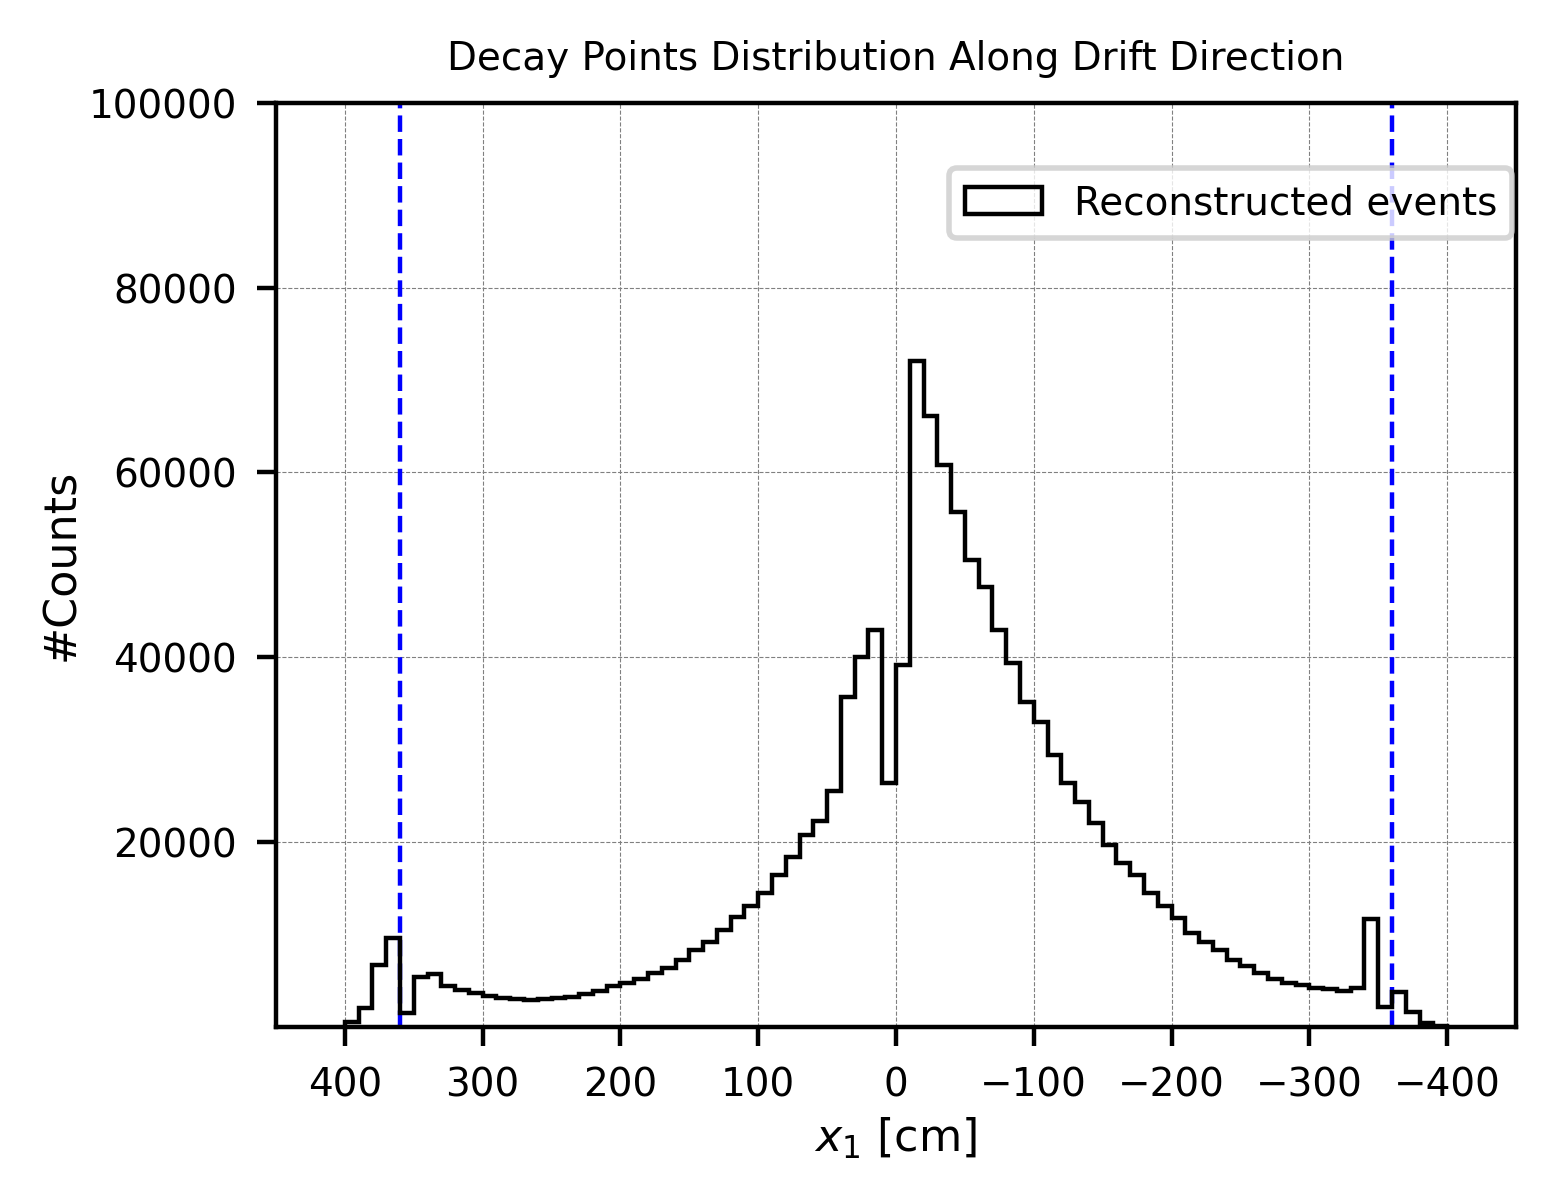

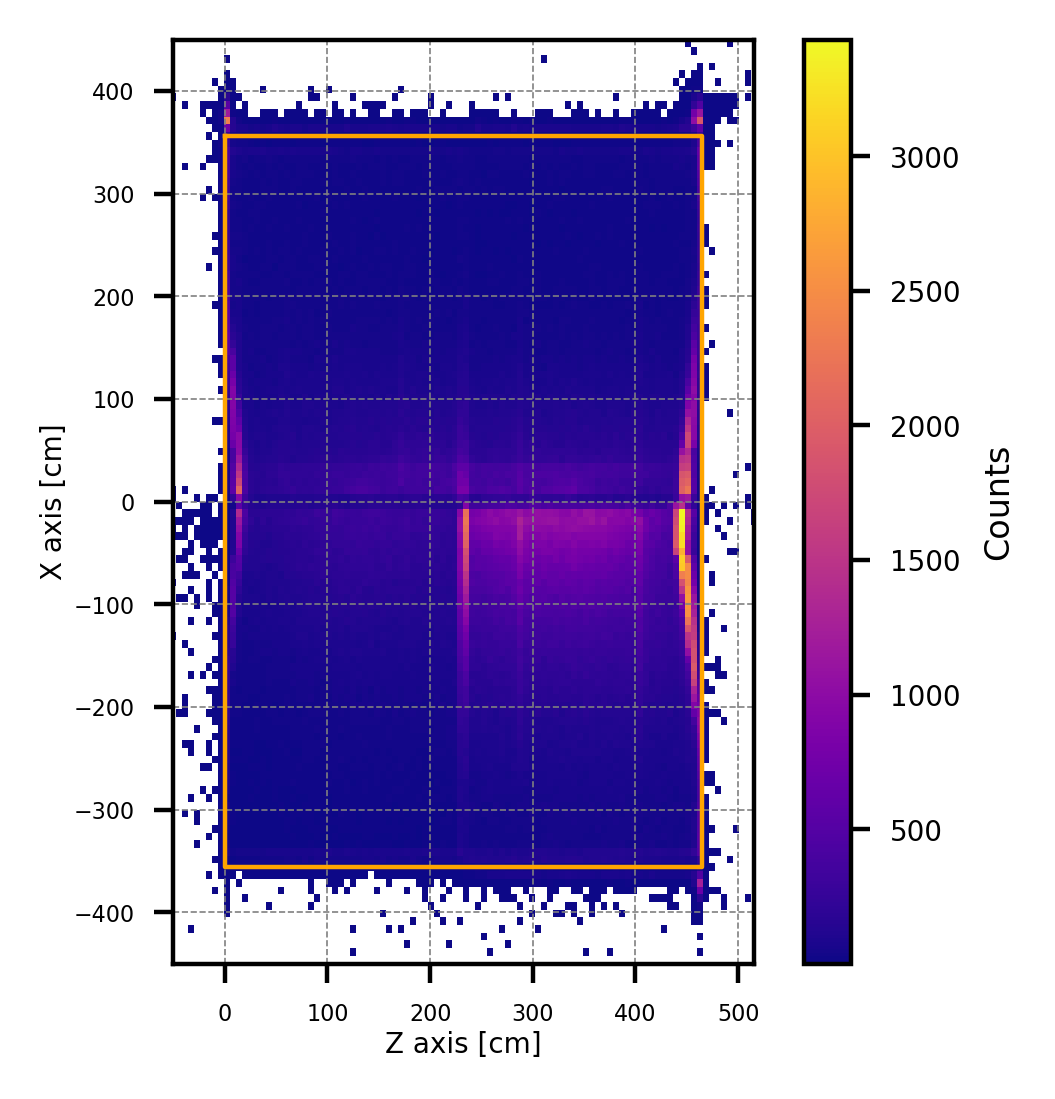

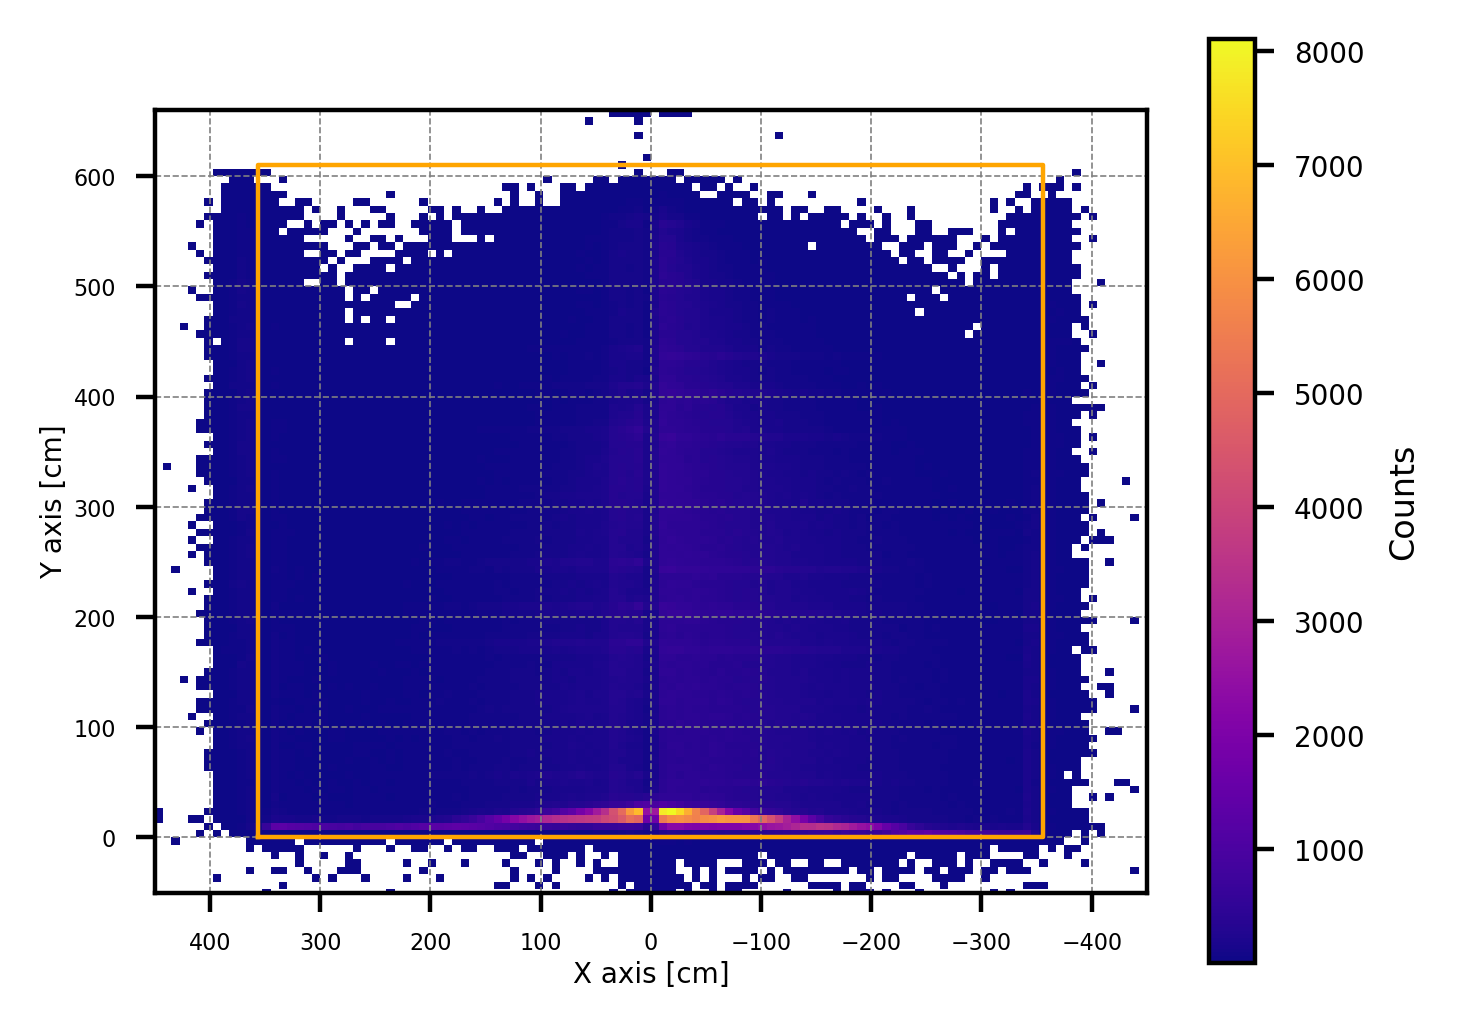

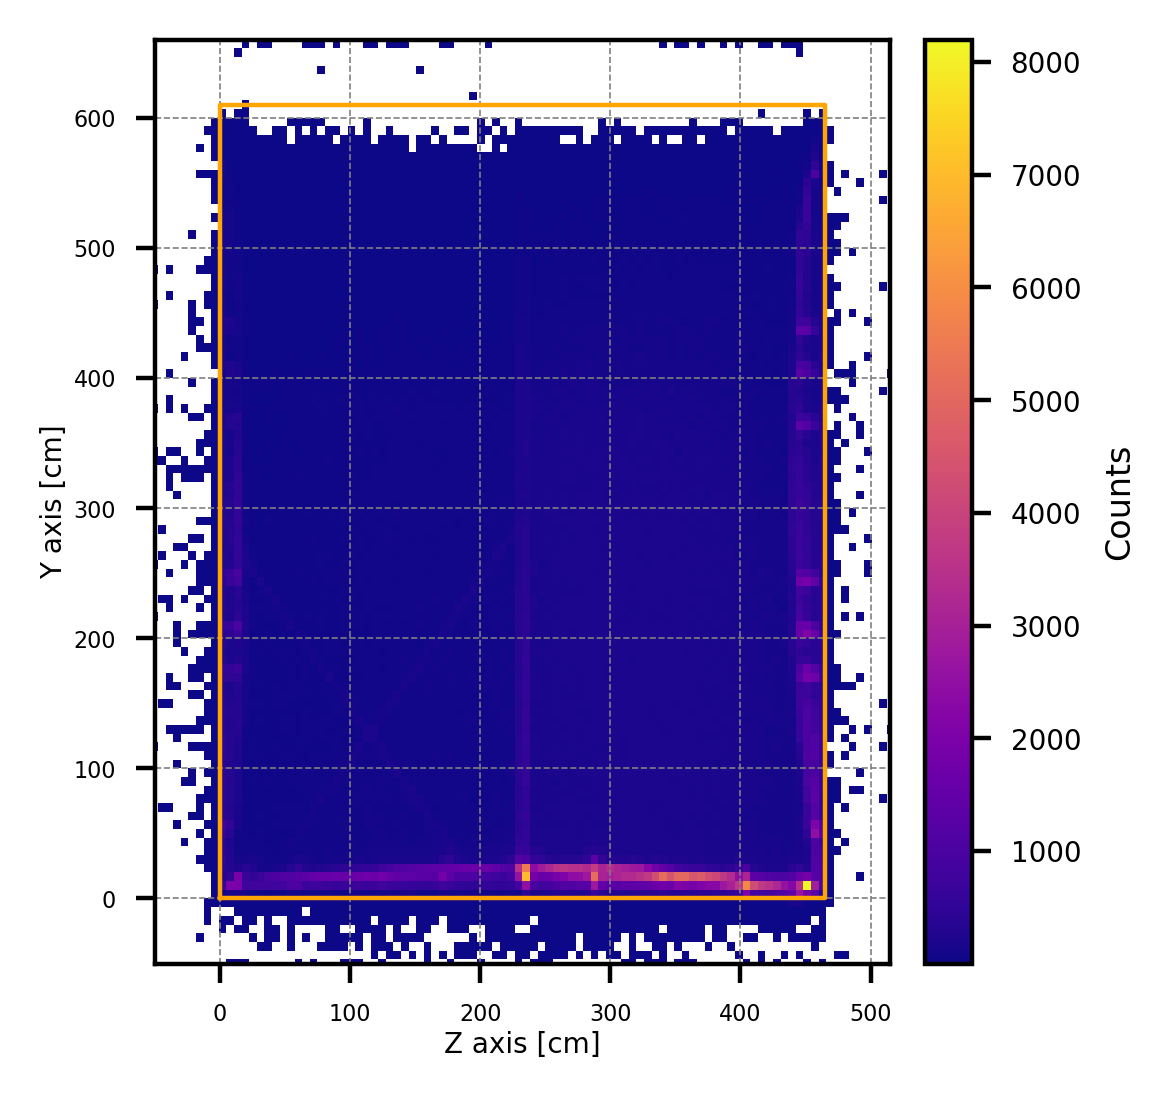

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

#Start drawing figures======================================    
#Set the limts of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

#Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465



#Initial values:
vals_decayX_initial = [ev.decayX_initial for ev in events_reco]
vals_decayY_initial = [ev.decayY_initial for ev in events_reco]
vals_decayZ_initial = [ev.decayZ_initial for ev in events_reco]

vals_startX_initial = [ev.startX_initial for ev in events_reco]
vals_startY_initial = [ev.startY_initial for ev in events_reco]
vals_startZ_initial = [ev.startZ_initial for ev in events_reco]

vals_MS_initial = [ev.MS_initial for ev in events_reco]
vals_MH_initial = [ev.MH_initial for ev in events_reco]





#Decay points distribution:==========================================
print("\nDecay points distribution: ")

decayX_initial = np.array(decayX_initial)
neg_X = np.sum(decayX_initial < 0)
pos_X = np.sum(decayX_initial >= 0)

num_negX = len([ev for ev in events_reco if ev.decayX_initial < 0])
num_posX = len([ev for ev in events_reco if ev.decayX_initial > 0])

print("# of X < 0 : ", num_negX, "({:.2f}%)".format(num_negX/len(events_reco)*100))
print("# of X >= 0: ", num_posX, "({:.2f}%)".format(num_posX/len(events_reco)*100))



# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-360, -360], [0, 100000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 100000], color="blue", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)


plt.hist(vals_decayX_initial, bins=bins, range=(range_min, range_max), edgecolor='black', 
         histtype='step', linewidth=0.8, label="Reconstructed events")


plt.xlim(-450, 450)
plt.xlabel(r'$x_1$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0.1, 100000)
#plt.yscale('log')
plt.title('Decay Points Distribution Along Drift Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.77, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show()  






#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="orange", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayZ_initial, vals_decayX_initial, bins=(120, 120), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
#plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

plt.savefig('ch8_decayTop_initial_Data.png', dpi=600, bbox_inches='tight')

plt.show()







#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="orange", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayX_initial, vals_decayY_initial, bins=(120, 120), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
#plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

plt.savefig('ch8_decayFront_initial_Data.png', dpi=600, bbox_inches='tight')

plt.show() 




#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="orange", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayZ_initial, vals_decayY_initial, bins=(120, 120), range=[[zmin, zmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.2)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
#plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
#plt.title('Side View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

plt.savefig('ch8_decaySide_initial_Data.png', dpi=600, bbox_inches='tight')

plt.show() 












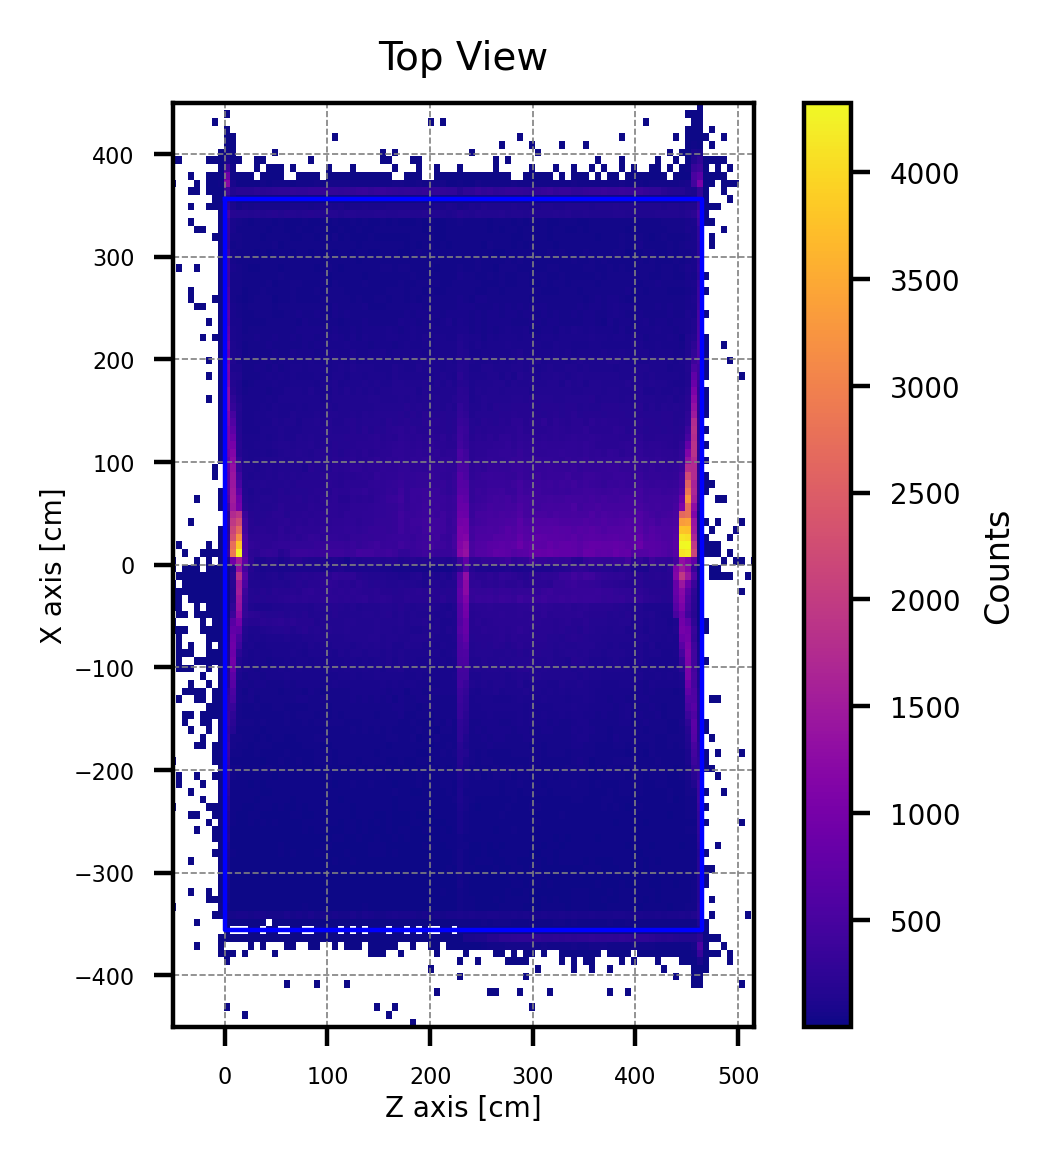

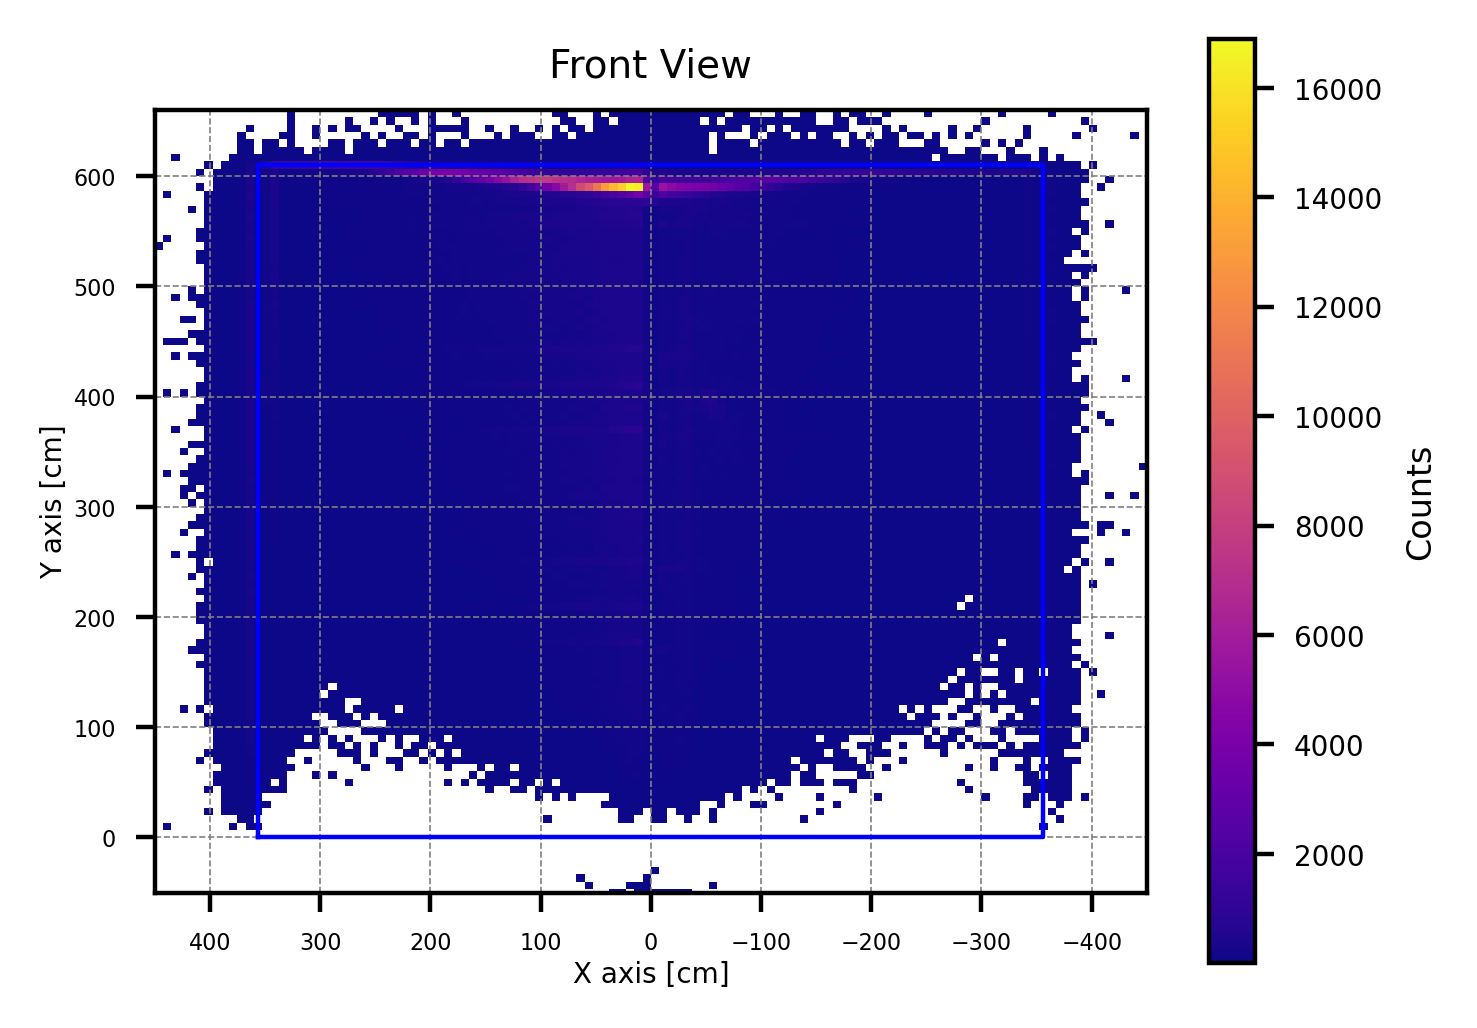

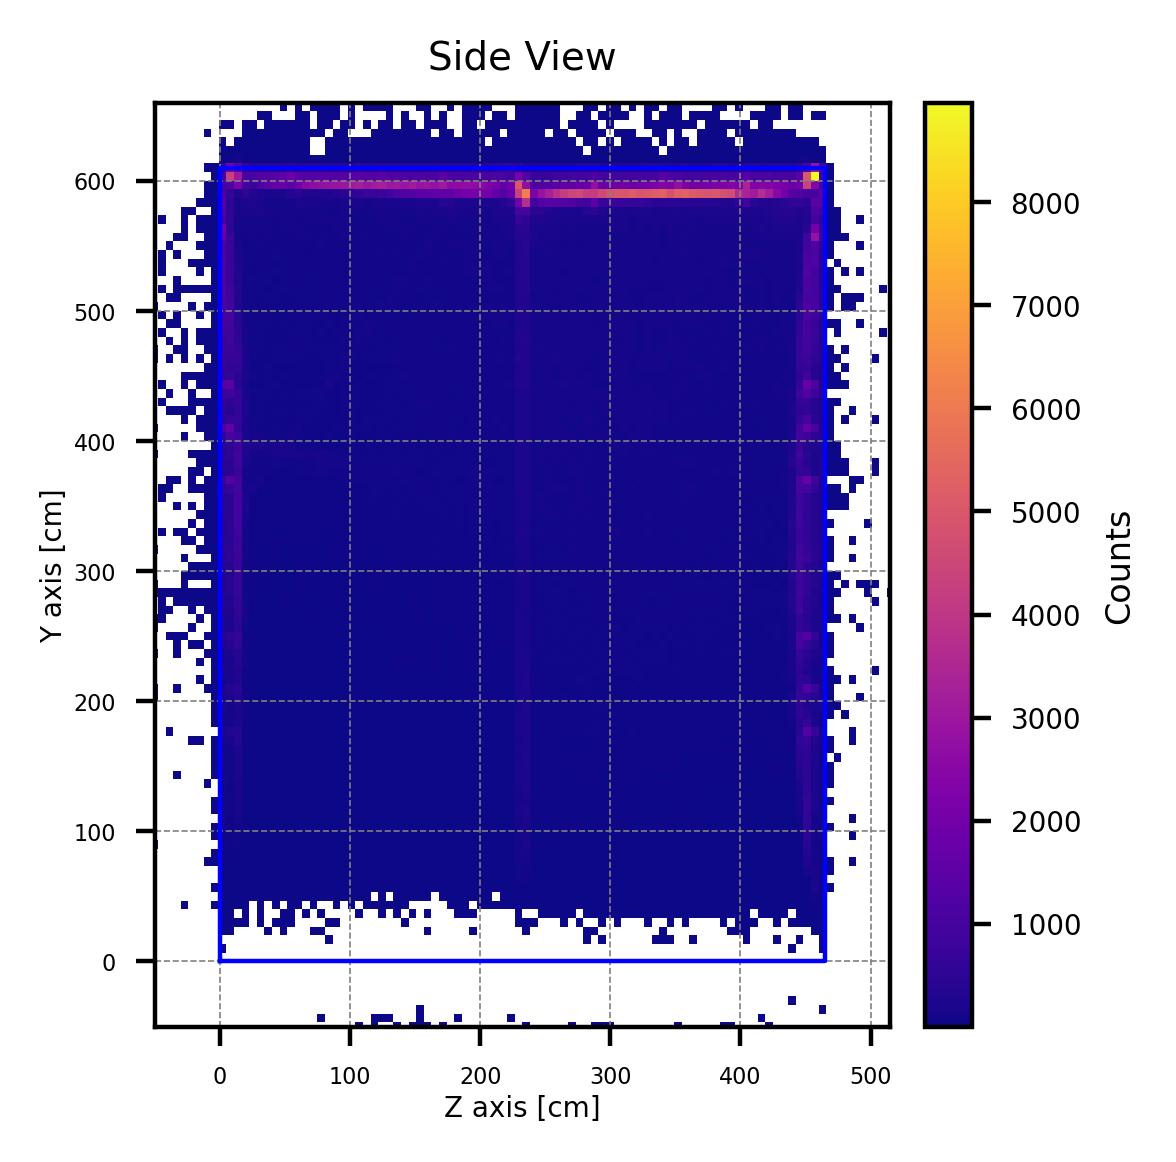

In [5]:
#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_startZ_initial, vals_startX_initial, bins=(120, 120), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()





#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_startX_initial, vals_startY_initial, bins=(120, 120), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 




#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_startZ_initial, vals_startY_initial, bins=(120, 120), range=[[zmin, zmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.2)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
#plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Side View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 

#### Michel score and Michel hits:

Data and MC drawing together. Data: points with statistical error bars
MC: histogram. Normalize!

Data entries = 1257997
MC entries   = 1868965
MC scale     = 0.6730982121120513
Data histogram integral = 1257997
MC histogram integral   = 1257997.0000010508


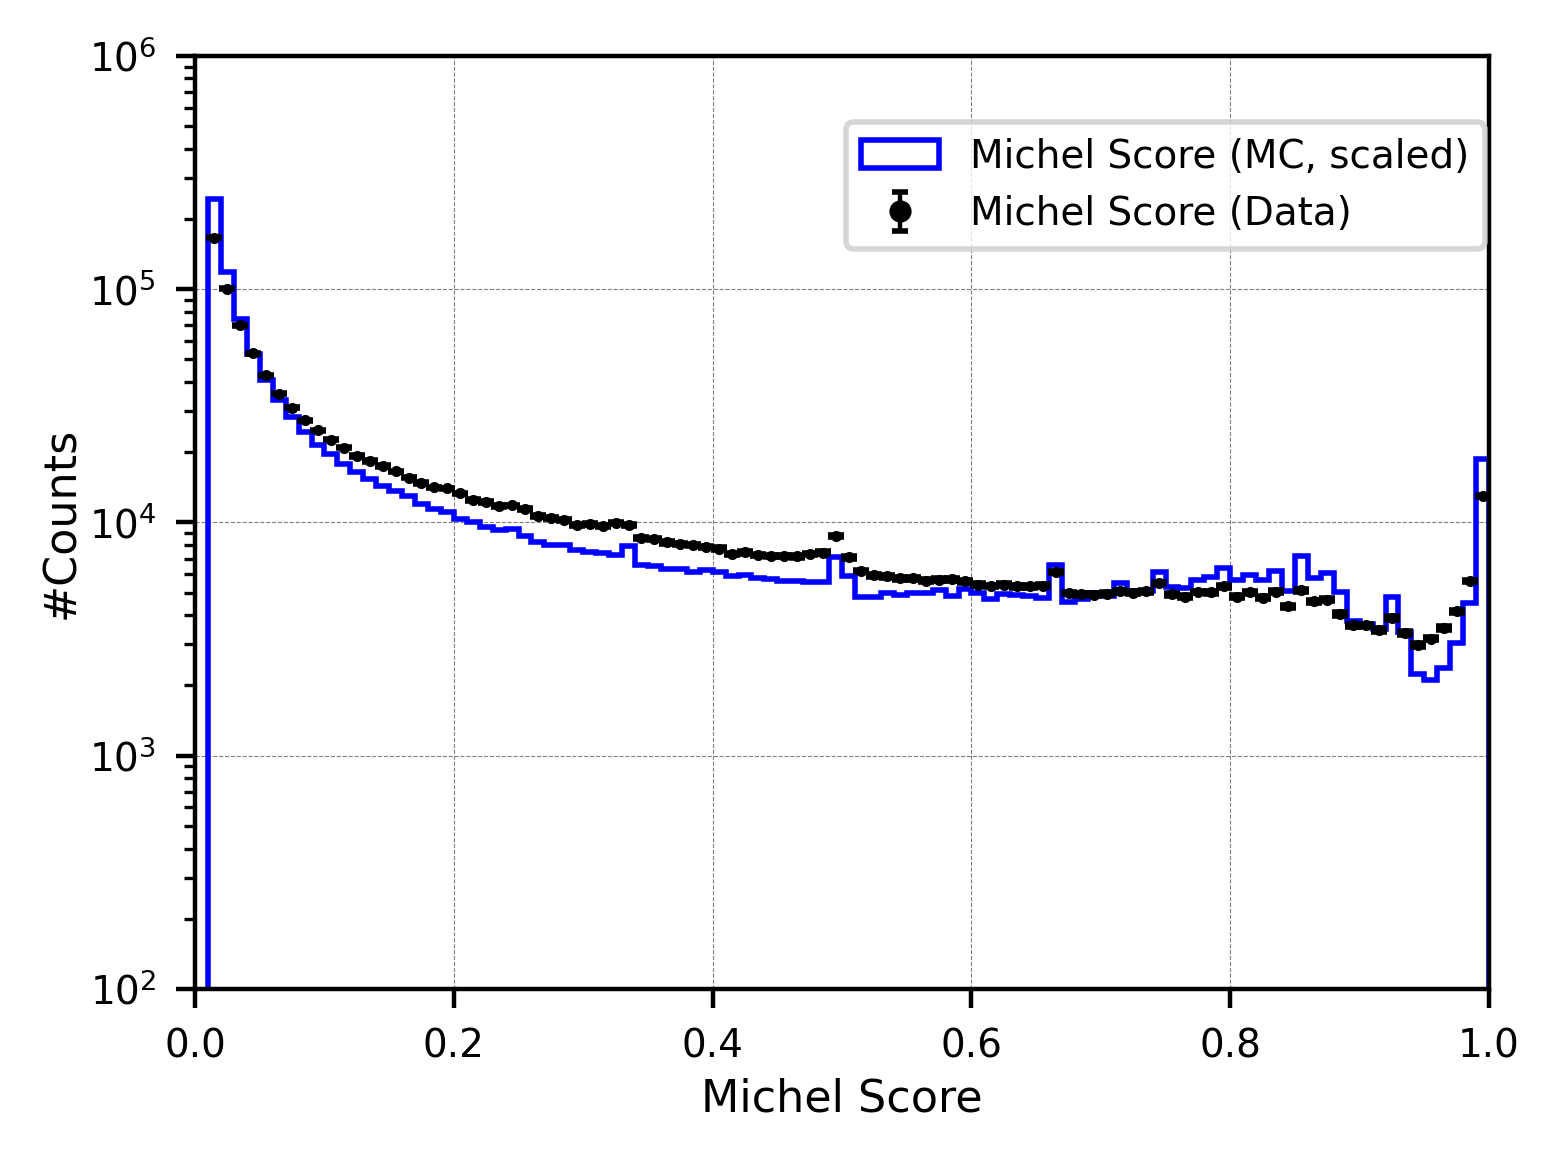

Data entries = 1257997
MC entries   = 1868965
MC scale     = 0.6730982121120513
Data histogram integral = 1257883
MC histogram integral   = 1257767.4735107194


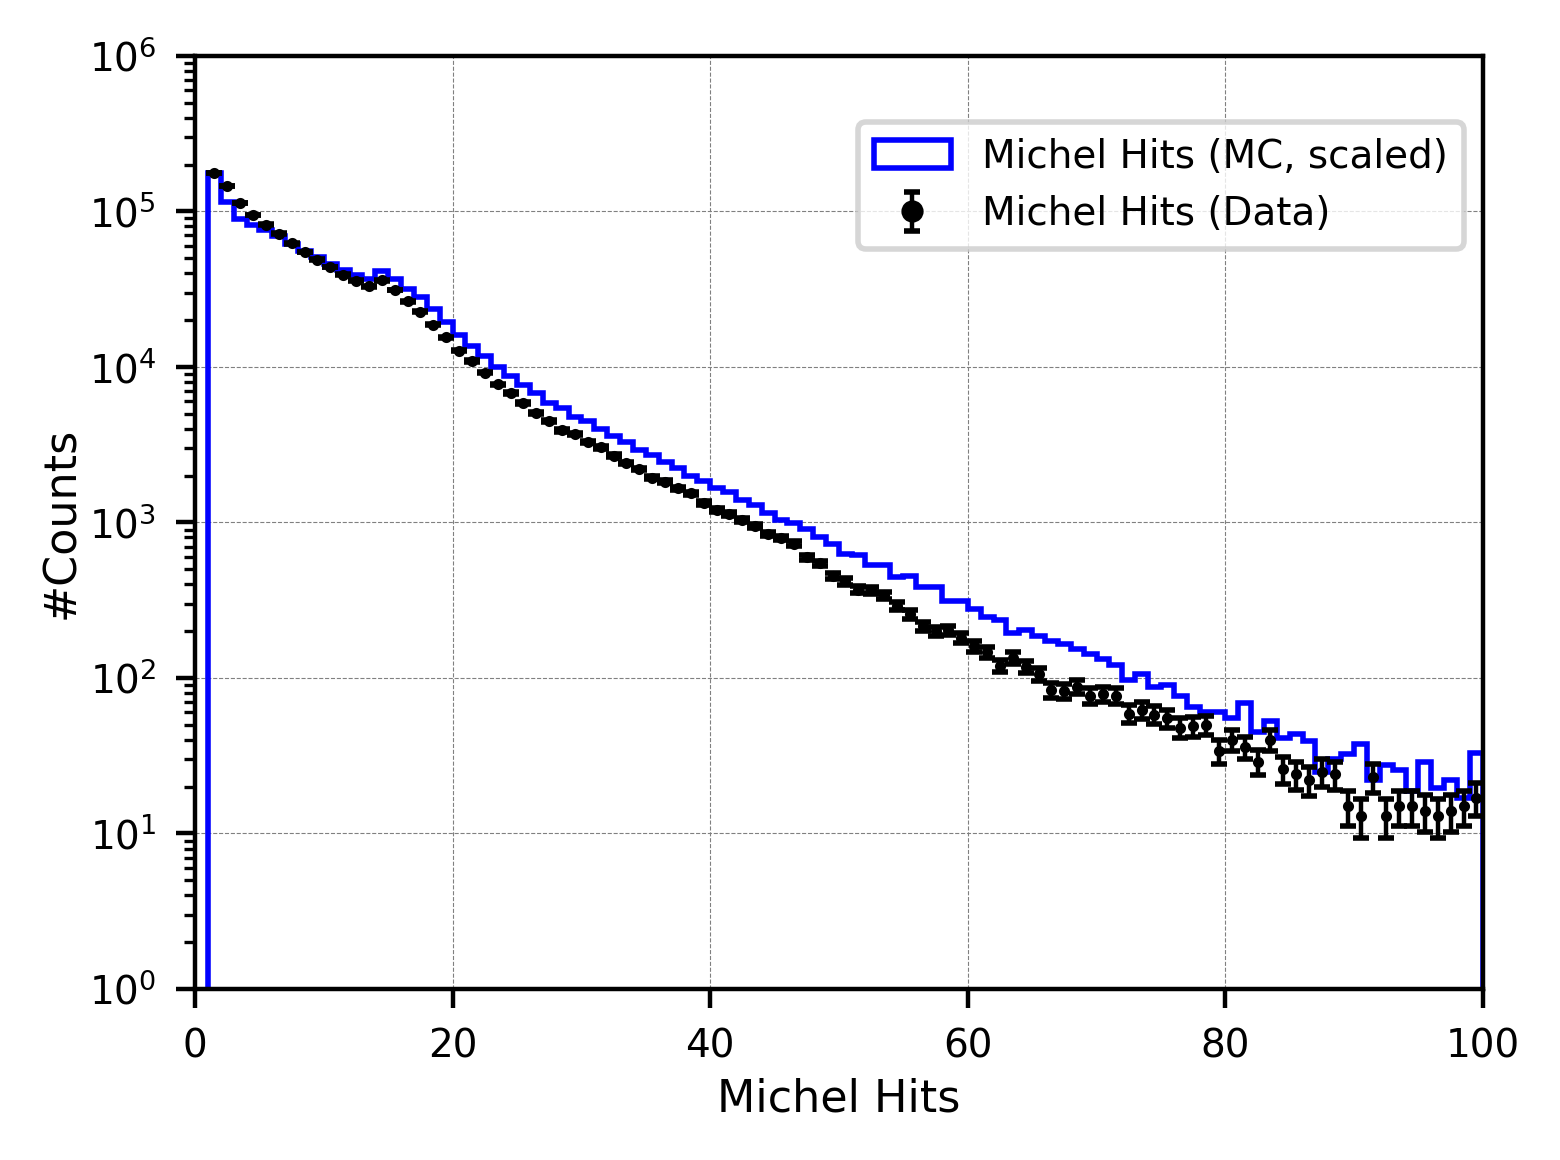

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# ======================================================================
# Read MC
# ======================================================================
vals_MS_initial_MC = np.load("../MC_official2025/vals_MS_initial_MC.npy")
vals_MH_initial_MC = np.load("../MC_official2025/vals_MH_initial_MC.npy")


# ======================================================================
# Binning
# ======================================================================
bin_width = 0.01
range_min = 0.0
range_max = 1.0

bins = np.arange(range_min, range_max + bin_width, bin_width)

# ======================================================================
# Scale MC to Data
# ======================================================================
n_data = len(vals_MS_initial)
n_mc   = len(vals_MS_initial_MC)

mc_scale = n_data / n_mc

print("Data entries =", n_data)
print("MC entries   =", n_mc)
print("MC scale     =", mc_scale)

mc_weights = np.full(len(vals_MS_initial_MC), mc_scale)

# ======================================================================
# Data histogram
# ======================================================================
data_counts, bin_edges = np.histogram(vals_MS_initial,bins=bins)
data_errors = np.sqrt(data_counts)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0

# Histogram integrals
mc_counts, _ = np.histogram(vals_MS_initial_MC, bins=bins, weights=mc_weights)

print("Data histogram integral =", np.sum(data_counts))
print("MC histogram integral   =", np.sum(mc_counts))

# ======================================================================
# Plot
# ======================================================================
plt.figure(figsize=(4,3), dpi=400)

# MC histogram (scaled to Data)
plt.hist(vals_MS_initial_MC, bins=bins, weights=mc_weights, histtype='step', edgecolor='blue',
    linewidth=1.0, label='Michel Score (MC, scaled)')

# Data points with statistical uncertainties
plt.errorbar(bin_centers, data_counts, yerr=data_errors, fmt='o', color='black', markersize=1.0,
    linewidth=0.8, capsize=1.5, label='Michel Score (Data)')

# ======================================================================
# Style
# ======================================================================
plt.xlim(range_min, range_max)

plt.xlabel('Michel Score', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(100, 1e6)
plt.yscale('log')
#plt.title('Initial Michel Score Distribution', fontsize=7)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.legend(loc='upper center', bbox_to_anchor=(0.75, 0.95), fontsize=10, markerscale=3, ncol=1,
    prop={'size':7})

plt.tight_layout()

# Save
plt.savefig("ch8_MS_initial_MCvsData.png", dpi=600, bbox_inches='tight')

plt.show()









# Michel Hits---------------------------------------------------

# ======================================================================
# Binning
# ======================================================================
bin_width = 1
range_min = 0
range_max = 100

bins = np.arange(range_min, range_max + bin_width, bin_width)

# ======================================================================
# Scale MC to Data
# ======================================================================
n_data = len(vals_MH_initial)
n_mc   = len(vals_MH_initial_MC)

mc_scale = n_data / n_mc

print("Data entries =", n_data)
print("MC entries   =", n_mc)
print("MC scale     =", mc_scale)

mc_weights = np.full(len(vals_MH_initial_MC), mc_scale)

# ======================================================================
# Data histogram
# ======================================================================
data_counts, bin_edges = np.histogram(vals_MH_initial,bins=bins)
data_errors = np.sqrt(data_counts)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0

# ======================================================================
# MC histogram (scaled)
# ======================================================================
mc_counts, _ = np.histogram(vals_MH_initial_MC, bins=bins, weights=mc_weights)

print("Data histogram integral =", np.sum(data_counts))
print("MC histogram integral   =", np.sum(mc_counts))

# ======================================================================
# Plot
# ======================================================================
plt.figure(figsize=(4,3), dpi=400)

# MC
plt.hist(vals_MH_initial_MC, bins=bins, weights=mc_weights, histtype='step', edgecolor='blue',
    linewidth=1.0, label='Michel Hits (MC, scaled)')

# Data
plt.errorbar(bin_centers, data_counts, yerr=data_errors, fmt='o', color='black', markersize=1.0,
    linewidth=0.8, capsize=1.5, label='Michel Hits (Data)')

# ======================================================================
# Style
# ======================================================================
plt.xlim(0, 100)

plt.xlabel('Michel Hits', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)

plt.ylim(1, 1e6)
plt.yscale('log')
#plt.title('Initial Michel Hits Distribution', fontsize=7)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.75, 0.95), fontsize=10, markerscale=3, ncol=1,
    prop={'size':7})
plt.tight_layout()
plt.savefig("ch8_MH_initial_MCvsData.png", dpi=600, bbox_inches='tight')
plt.show()




#### Starting Points Distribution:

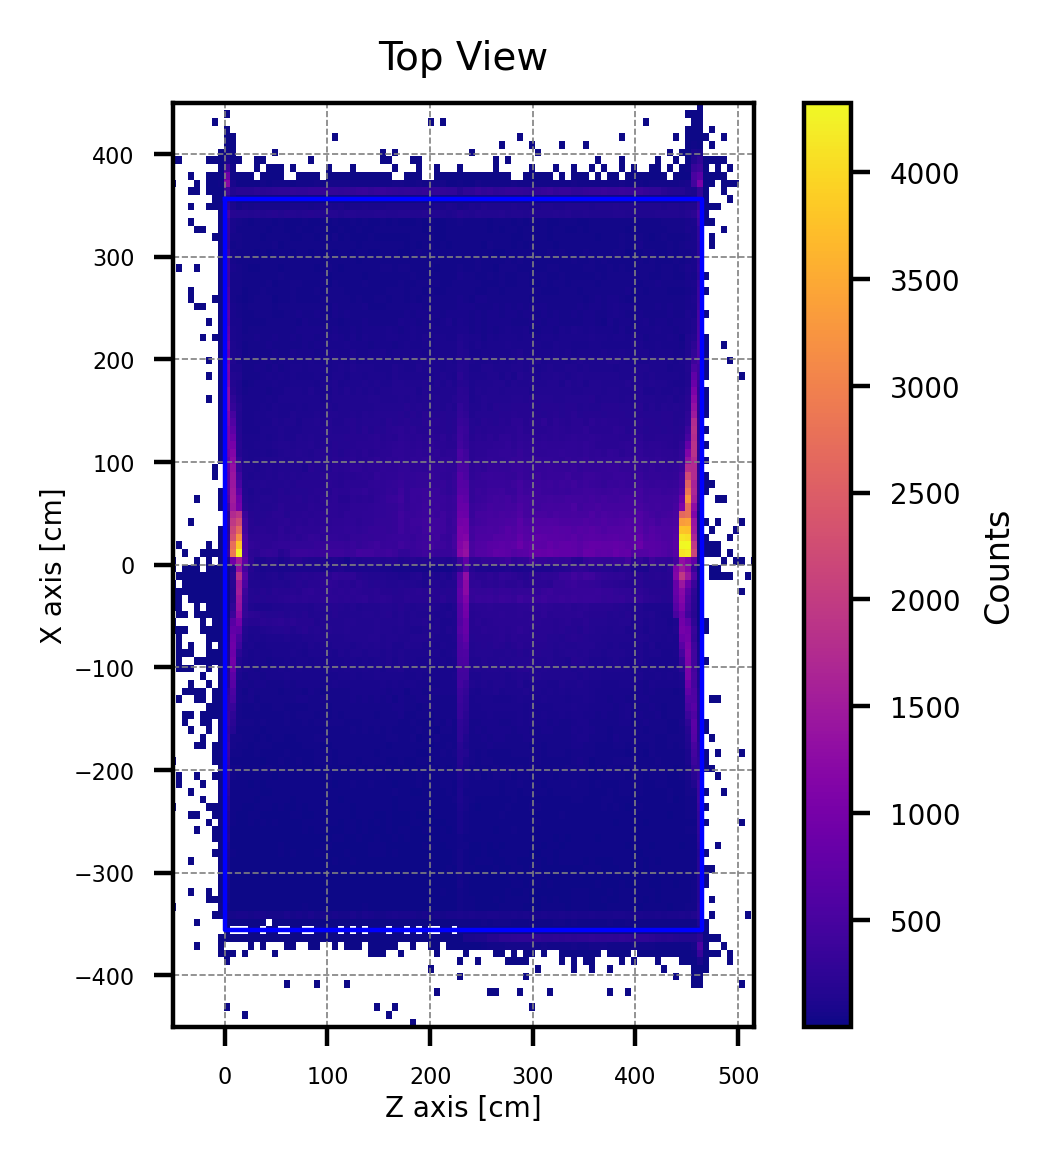

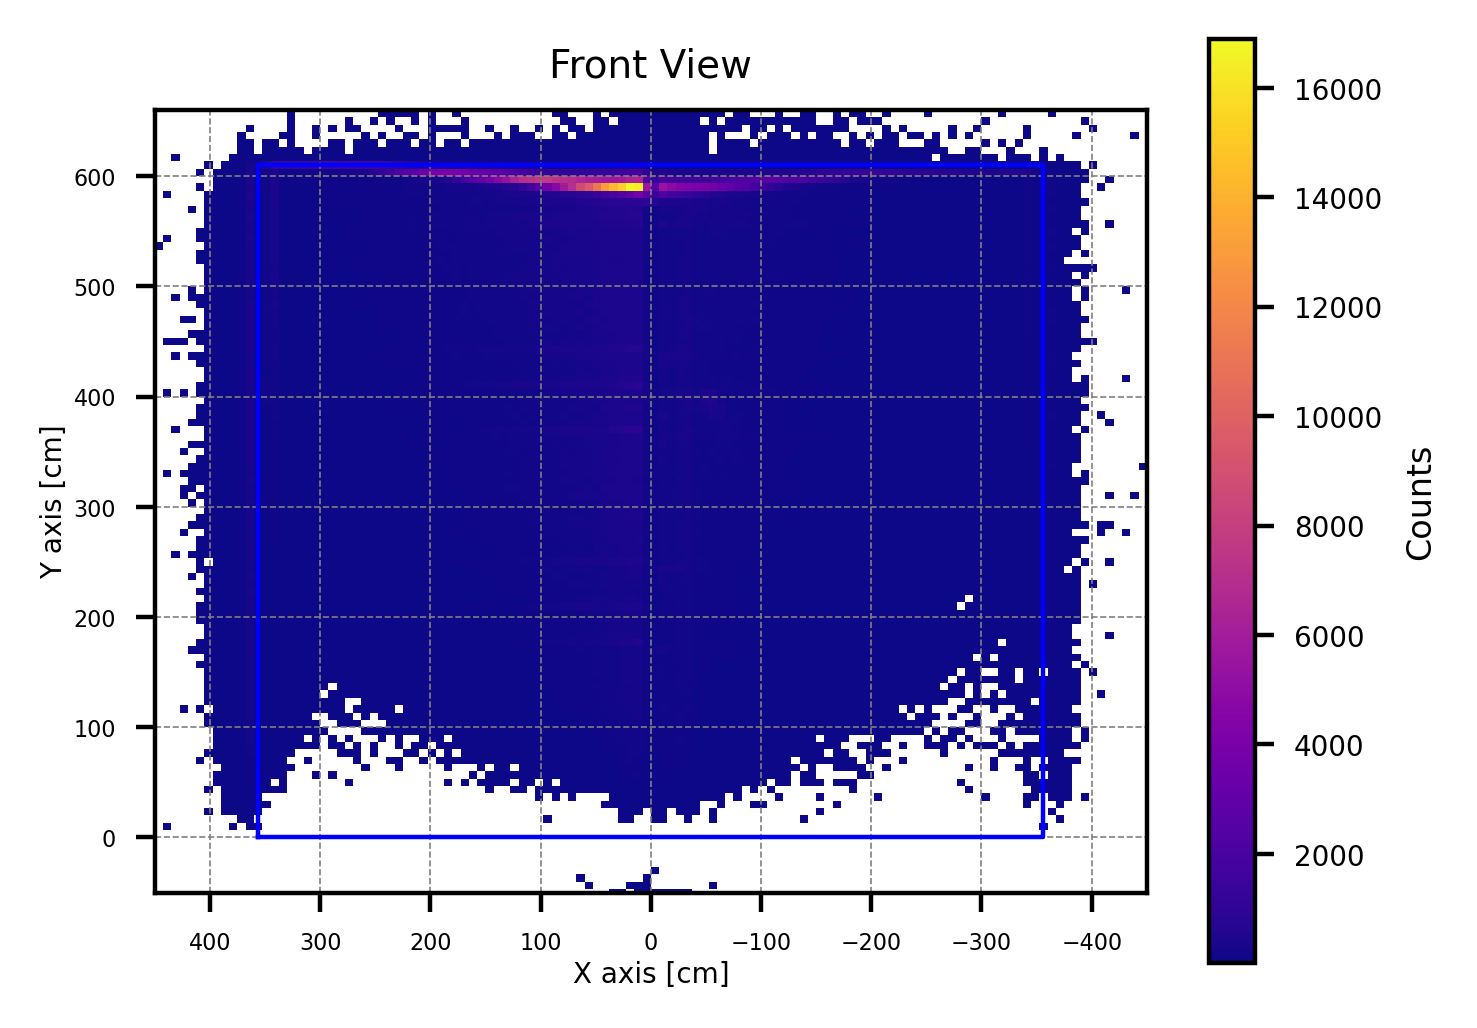

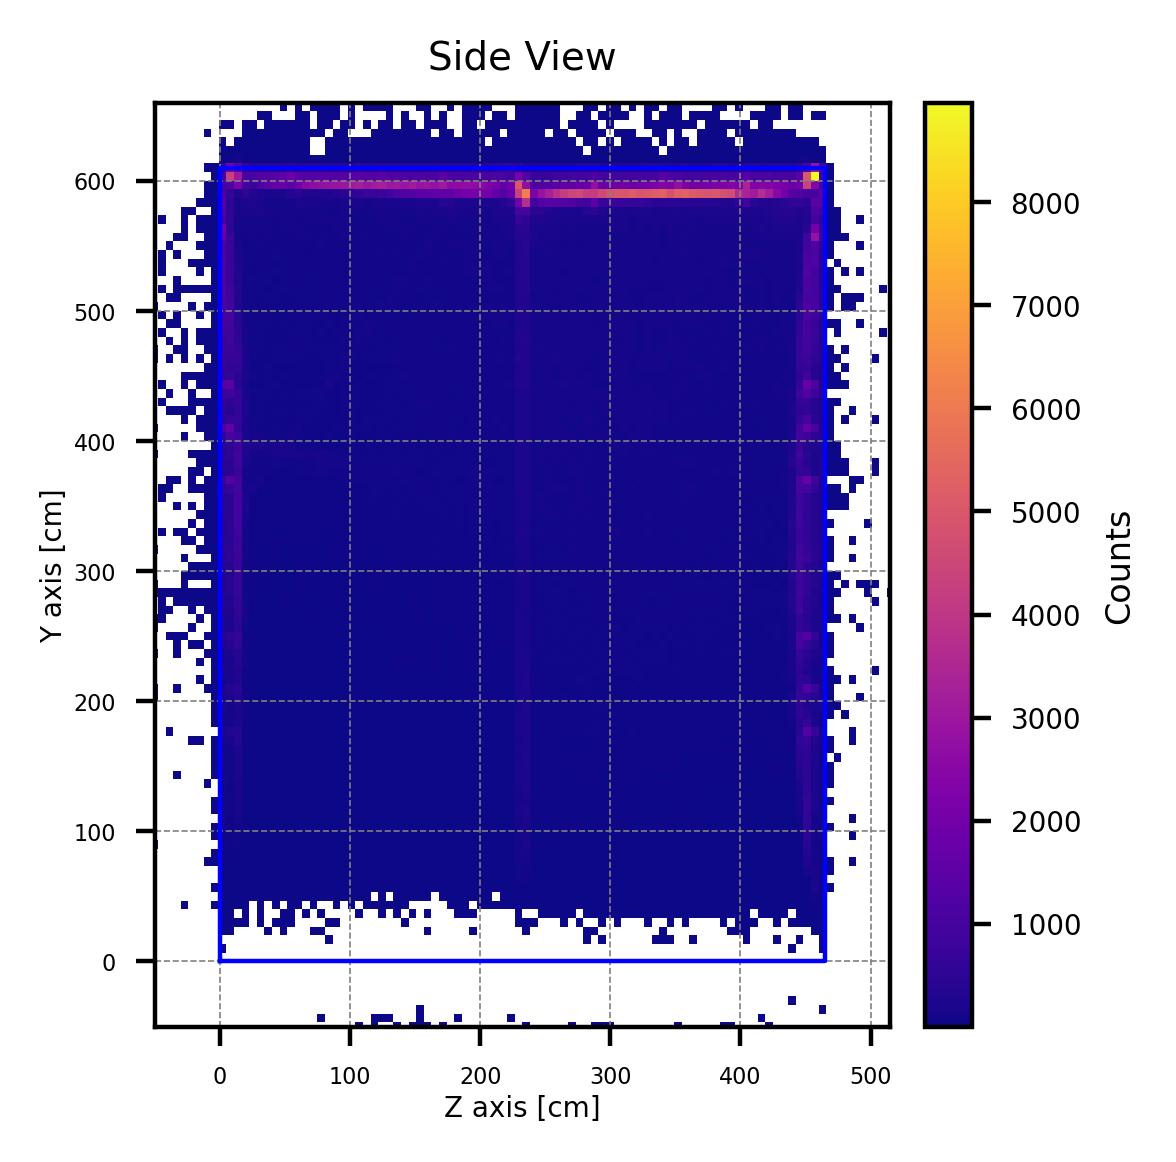

In [8]:
#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_startZ_initial, vals_startX_initial, bins=(120, 120), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()





#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_startX_initial, vals_startY_initial, bins=(120, 120), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 




#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_startZ_initial, vals_startY_initial, bins=(120, 120), range=[[zmin, zmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.2)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
#plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Side View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 

<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />

## TPC cuts:


### Apply cuts gradually:

In [9]:
Space_events_reco = []
MS_events_reco = []
MH_events_reco = [] # After Space & MS & MH cuts---



#Selection------
for ev in events_reco:
    X = ev.decayX_initial
    Y = ev.decayY_initial
    Z = ev.decayZ_initial
    MS = ev.MS_initial
    MH = ev.MH_initial

        
    #Default region: 0<y<610, 0<z<465 (SPACE CUT)---
    if -356 < X < 356 and 30 < Y < 580 and 30 < Z < 435:    
        Space_events_reco.append(ev)

        if 0.3 < MS: #(Michel score cut)---
            MS_events_reco.append(ev)
            
            if 3 <MH: #Michel hits cut---                
                MH_events_reco.append(ev)
                    
                    
                    

                    
#Initial size of dataset:-----
print("Reco events (initial): ", len(events_reco))

print("\nReco events (Space cut): ", len(Space_events_reco), "({:.2f}%)".format(len(Space_events_reco)/len(events_reco)*100))

print("\nReco events (Space & MS cuts): ", len(MS_events_reco), "({:.2f}%)".format(len(MS_events_reco)/len(events_reco)*100))

print("\nReco events (Space & MS & MH cuts): ", len(MH_events_reco), "({:.2f}%)".format(len(MH_events_reco)/len(events_reco)*100))





Reco events (initial):  1257997

Reco events (Space cut):  543533 (43.21%)

Reco events (Space & MS cuts):  186104 (14.79%)

Reco events (Space & MS & MH cuts):  159651 (12.69%)


### Apply all cuts:

In [10]:

TPC_events_reco = [] # After Space & MS & MH cuts---



#Selection------
for ev in events_reco:
    X = ev.decayX_initial
    Y = ev.decayY_initial
    Z = ev.decayZ_initial
    MS = ev.MS_initial
    MH = ev.MH_initial

        
    #Default region: 0<y<610, 0<z<465 (SPACE CUT)---
    if -356 < X < 356 and 30 < Y < 580 and 30 < Z < 435:    

        if 0.3 < MS: #(Michel score cut)---
            
            if 3 <MH: #Michel hits cut---                
                TPC_events_reco.append(ev)


print("\nReco events (Space & MS & MH cuts): ", len(TPC_events_reco), 
      "({:.2f}%)".format(len(TPC_events_reco)/len(events_reco)*100))




Reco events (Space & MS & MH cuts):  159651 (12.69%)


Decay points distribution (After TPC cut): 
# of X < 0 :  115972 (72.641%)
# of X >= 0:  43679 (27.359%)

#decayX_TPC (total):  159651
#decayX_apa1:  18466 (11.57%)
#decayX_apa2:  97506 (61.07%)
#decayX_apa3:  19618 (12.29%)
#decayX_apa4:  24061 (15.07%)


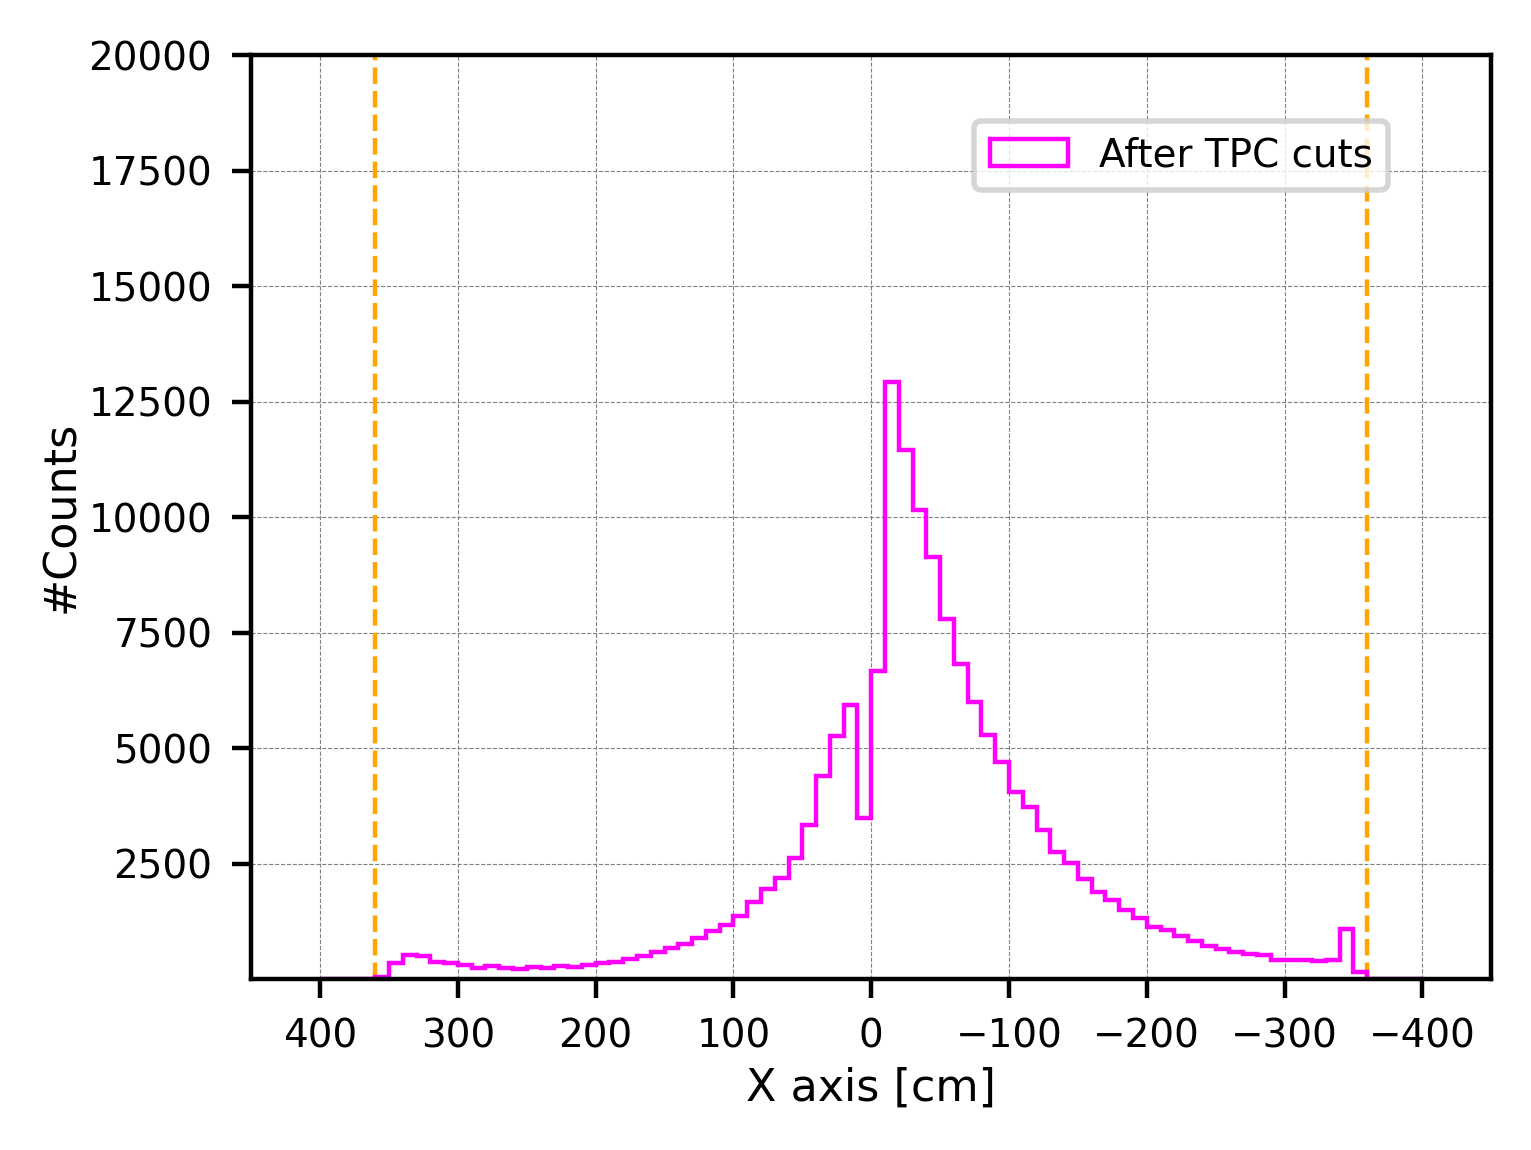

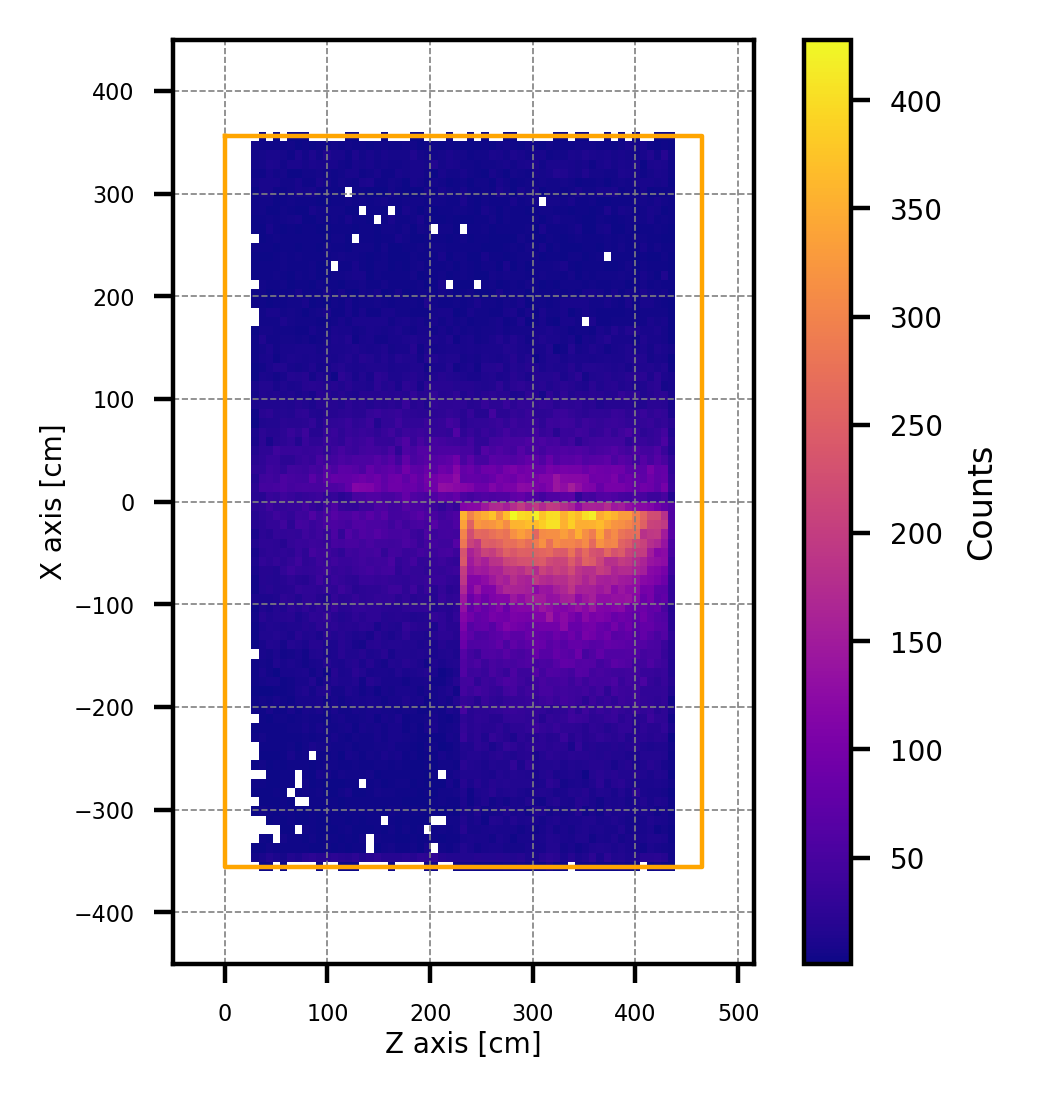

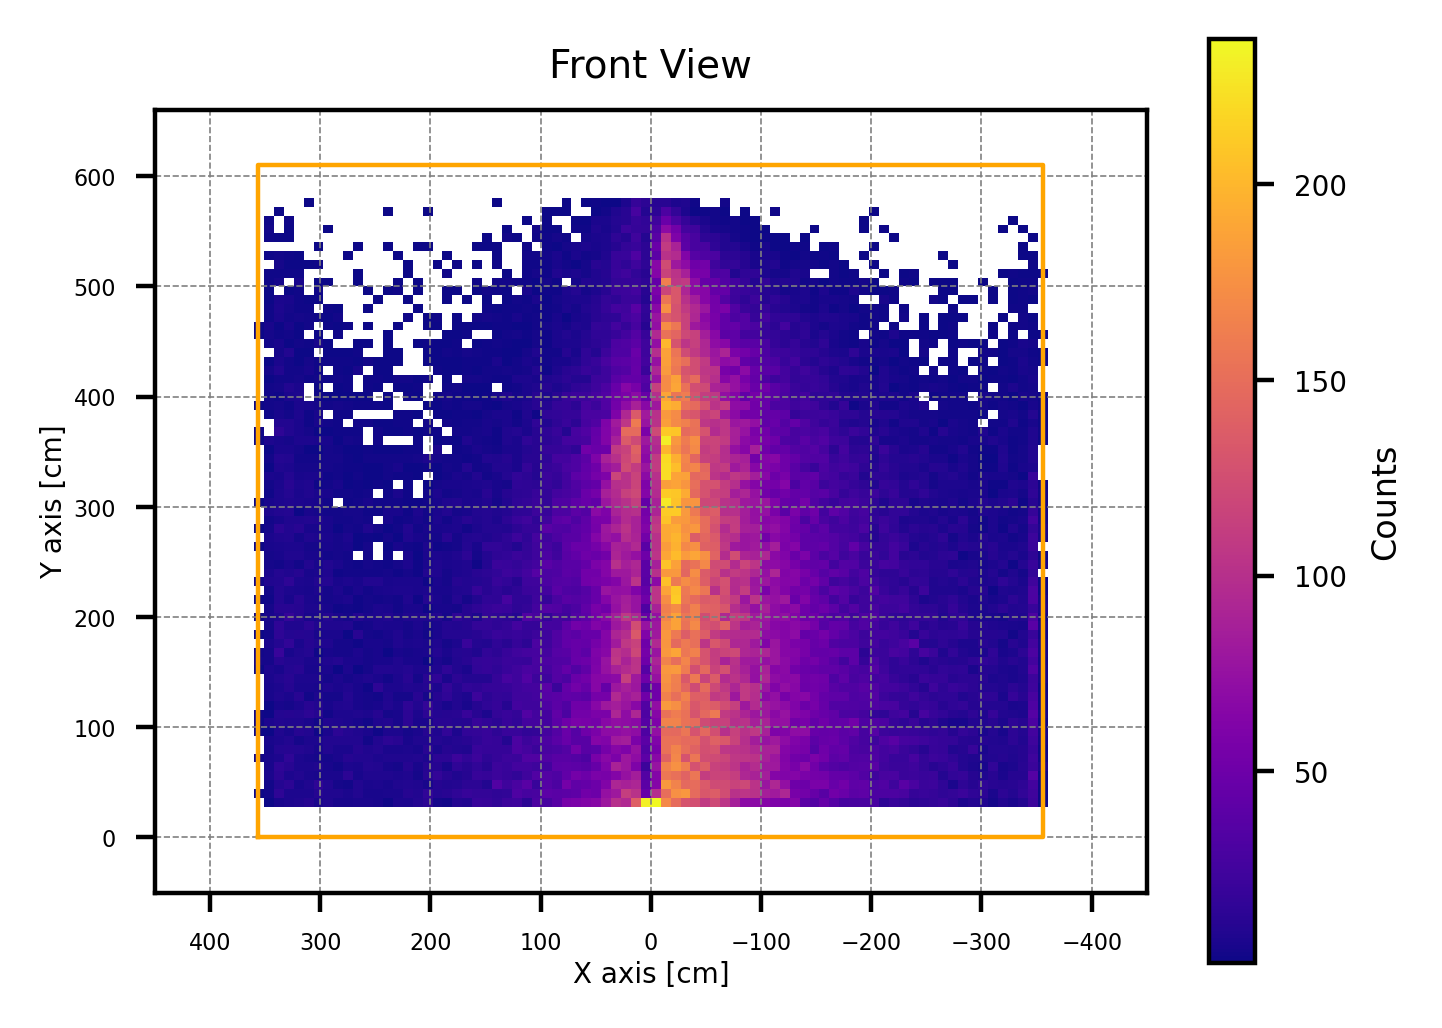

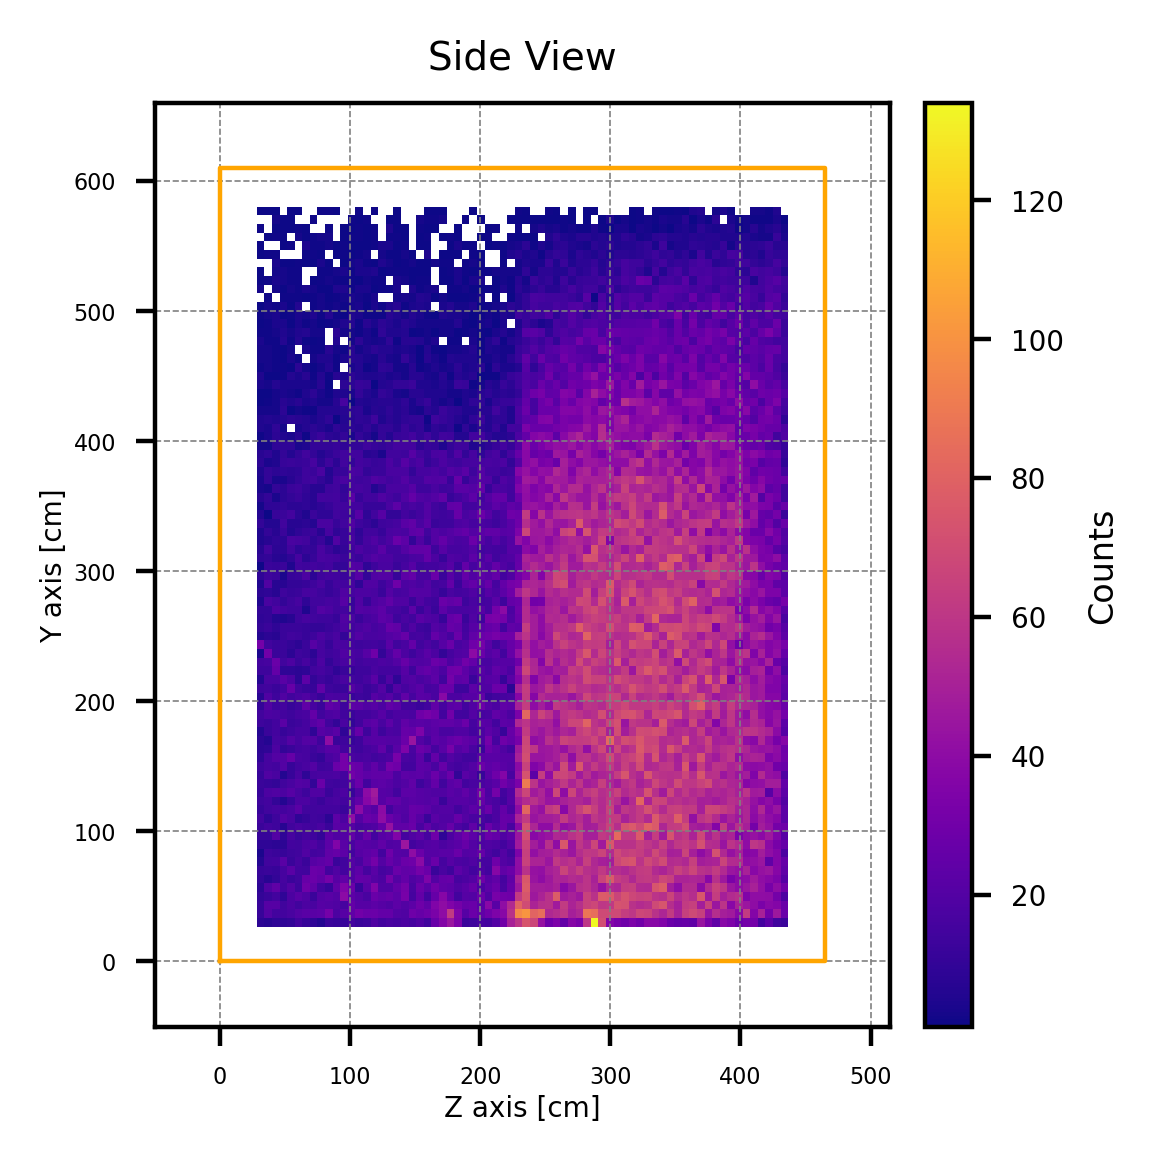

In [46]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

#Start drawing figures======================================    
#Set the limts of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

#Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465



TPC_X = [ev.decayX_initial for ev in TPC_events_reco]
TPC_Y = [ev.decayY_initial for ev in TPC_events_reco]
TPC_Z = [ev.decayZ_initial for ev in TPC_events_reco]
TPC_MS = [ev.MS_initial for ev in TPC_events_reco]
TPC_MH = [ev.MH_initial for ev in TPC_events_reco]
TPC_startX = [ev.startX_initial for ev in TPC_events_reco]
TPC_startZ = [ev.startZ_initial for ev in TPC_events_reco]
TPC_startY = [ev.startY_initial for ev in TPC_events_reco]



#Decay points distribution:==========================================
print("Decay points distribution (After TPC cut): ")

TPC_X = np.array(TPC_X)
neg_X = np.sum(TPC_X < 0)
pos_X = np.sum(TPC_X >= 0)
print("# of X < 0 : ", neg_X, "({:.3f}%)".format(neg_X/len(TPC_X)*100))
print("# of X >= 0: ", pos_X, "({:.3f}%)".format(pos_X/len(TPC_X)*100))



#Decay points in 4 APA regions:==========================================
decayX_apa1 = []
decayX_apa2 = []
decayX_apa3 = []
decayX_apa4 = []

decayZ_apa1 = []
decayZ_apa2 = []
decayZ_apa3 = []
decayZ_apa4 = []

#Do seperation:
for i in range(0, len(TPC_X)):
    z = TPC_Z[i]
    x = TPC_X[i]

    if x <= 0 and z <= 231.266: #APA1
        decayX_apa1.append(x)
        decayZ_apa1.append(z)              
    elif x <= 0 and z > 231.266: #APA2
        decayX_apa2.append(x)
        decayZ_apa2.append(z)        
    elif x > 0 and z <= 231.266: #APA3
        decayX_apa3.append(x)
        decayZ_apa3.append(z) 
    elif x > 0 and z > 231.266: #APA4
        decayX_apa4.append(x)
        decayZ_apa4.append(z) 


print("\n#decayX_TPC (total): ", len(TPC_X))
print("#decayX_apa1: ", len(decayX_apa1), "({:.2f}%)".format(len(decayX_apa1)/len(TPC_X)*100))
print("#decayX_apa2: ", len(decayX_apa2), "({:.2f}%)".format(len(decayX_apa2)/len(TPC_X)*100))
print("#decayX_apa3: ", len(decayX_apa3), "({:.2f}%)".format(len(decayX_apa3)/len(TPC_X)*100))
print("#decayX_apa4: ", len(decayX_apa4), "({:.2f}%)".format(len(decayX_apa4)/len(TPC_X)*100))








#Decay points distribution:==========================================



# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-360, -360], [0, 20000], color="orange", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 20000], color="orange", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)


#plt.hist(vals_decayX_initial, bins=bins, range=(range_min, range_max), edgecolor='black', 
#         histtype='step', linewidth=0.8, label="Initial Events")
plt.hist(TPC_X, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8, label="After TPC cuts")


plt.xlim(-450, 450)
plt.xlabel('X axis [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0.1, 20000)
#plt.yscale('log')
#plt.title('Distribution Along Drift Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.75, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.savefig('ch8_decayX_tpcCut_Data.png', dpi=600, bbox_inches='tight')

plt.show() 






#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="orange", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(TPC_Z, TPC_X, bins=(100, 100), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
#plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

plt.savefig('ch8_decayTop_tpcCut_Data.png', dpi=600, bbox_inches='tight')

plt.show()







#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="orange", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(TPC_X, TPC_Y, bins=(100, 100), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 








#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="orange", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(TPC_Z, TPC_Y, bins=(120, 120), range=[[zmin, zmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.2)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
#plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Side View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 





#### Remove Events in APA1:

In [ ]:
decayX_apa234 = []

decayX_apa234_MC = np.load("../MC_official2025/decayX_apa234_MC.npy") #official MC---

#Do seperation:
for i in range(0, len(TPC_X)):
    z = TPC_Z[i]
    x = TPC_X[i]

    if x <= 0 and z <= 231.266: #APA1
        continue             
    else:
        decayX_apa234.append(x)

print("#decayX_apa234: ", len(decayX_apa234), "/", len(TPC_X),
      "({:.2f}%)".format(len(decayX_apa234)/len(TPC_X)*100))

print("#decayX_apa234_MC: ", len(decayX_apa234_MC))

#decayX_apa234:  141185 / 159651 (88.43%)
#decayX_apa234_MC:  121669



### Data MC Comparison:

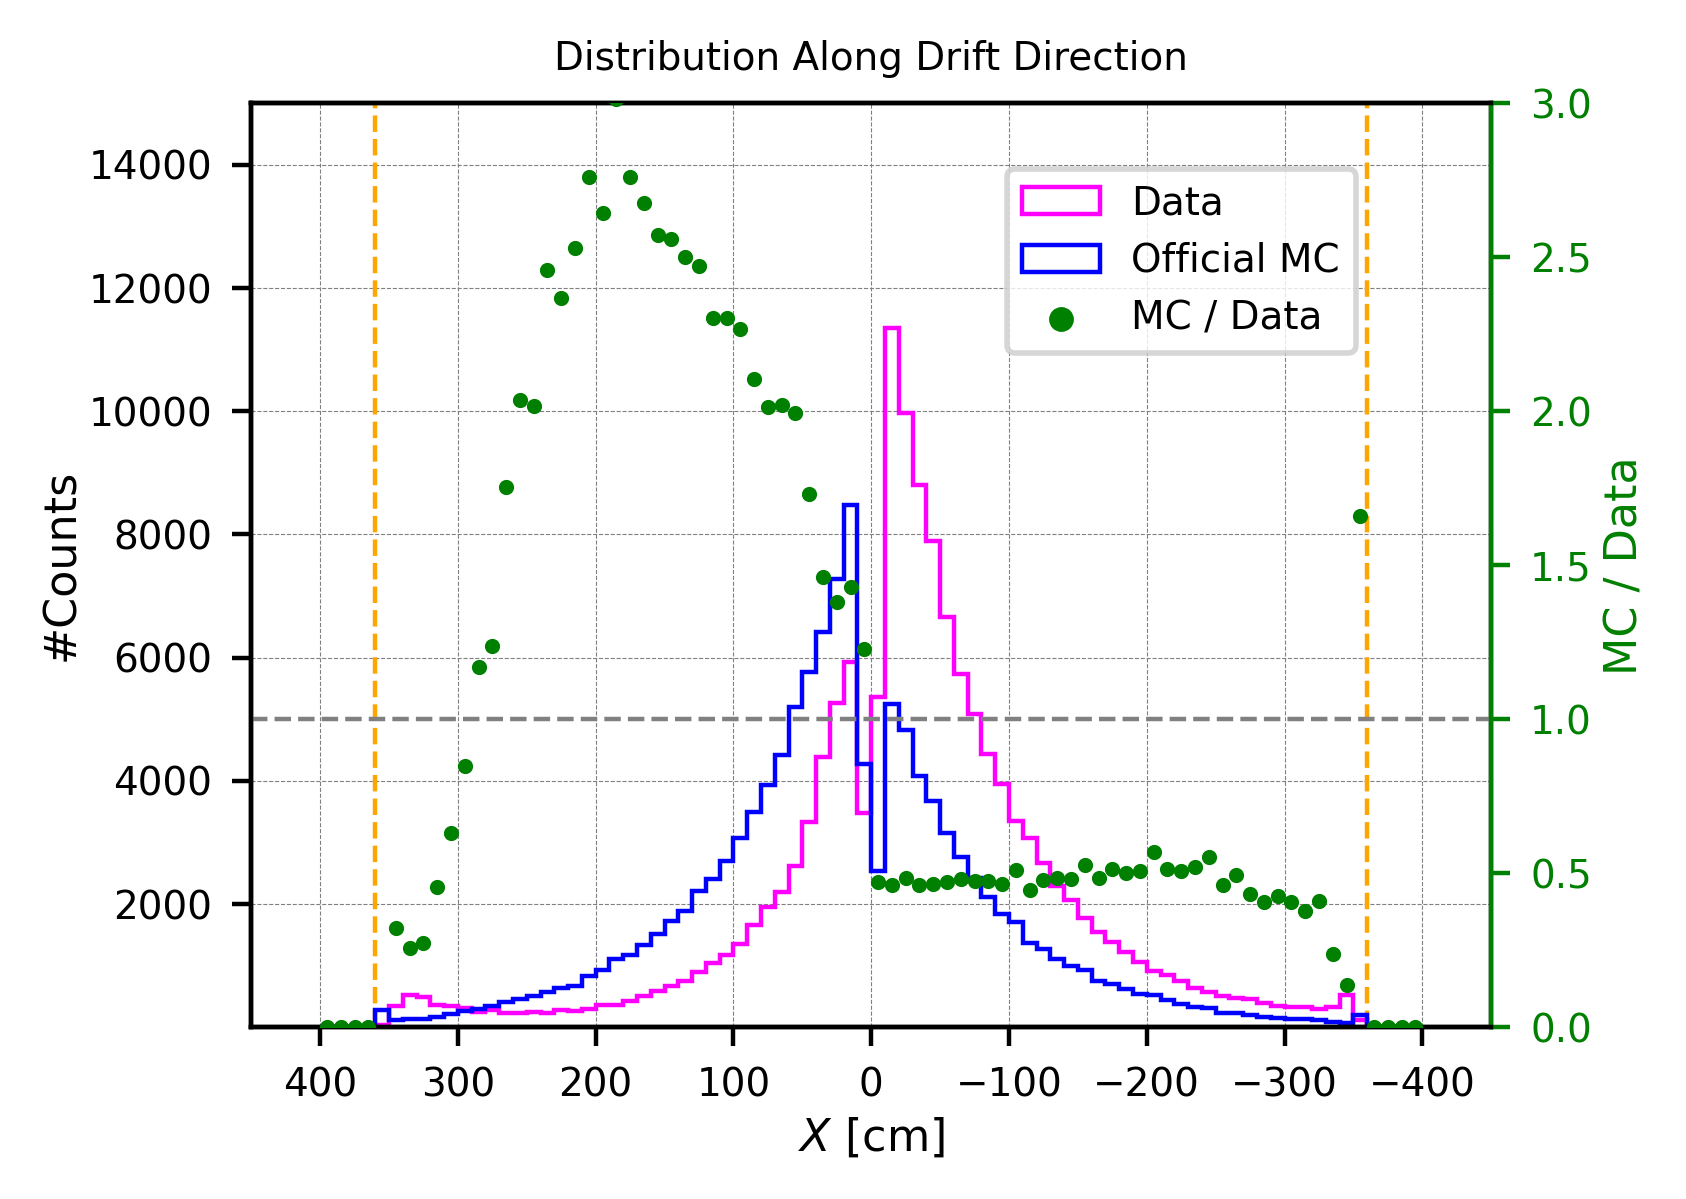

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4, 3), dpi=400)

# Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histograms for ratio calculation
data_counts, _ = np.histogram(decayX_apa234, bins=bins, range=(range_min, range_max))
mc_counts, _   = np.histogram(decayX_apa234_MC, bins=bins, range=(range_min, range_max))

# Bin centers
bin_centers = (bins[:-1] + bins[1:]) / 2

# Ratio = MC / Data
ratio = np.divide(
    mc_counts,
    data_counts,
    out=np.zeros_like(mc_counts, dtype=float),
    where=data_counts != 0
)

# Main axis
ax1 = plt.gca()

# APA planes
ax1.plot([-360, -360], [0, 15000], color="orange", linewidth=0.8, linestyle='--')
ax1.plot([360, 360], [0, 15000], color="orange", linewidth=0.8, linestyle='--')

# Histograms
ax1.hist(
    decayX_apa234,
    bins=bins,
    range=(range_min, range_max),
    edgecolor='magenta',
    histtype='step',
    linewidth=0.8,
    label="Data"
)

ax1.hist(
    decayX_apa234_MC,
    bins=bins,
    range=(range_min, range_max),
    edgecolor='blue',
    histtype='step',
    linewidth=0.8,
    label="Official MC"
)

# Main axis formatting
ax1.set_xlim(-450, 450)
ax1.set_xlabel(r'$X$ [cm]', labelpad=2, fontsize=8)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=8)
ax1.invert_xaxis()
ax1.set_ylim(0.1, 15000)
# ax1.set_yscale('log')
ax1.set_title('Distribution Along Drift Direction', fontsize=7)
ax1.tick_params(labelsize=7)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

# Right y-axis for ratio
ax2 = ax1.twinx()

ax2.scatter(
    bin_centers,
    ratio,
    color='green',
    s=3,
    label='MC / Data',
    zorder=5
)

ax2.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
ax2.set_ylabel('MC / Data', labelpad=2, fontsize=8, color="green")
ax2.set_ylim(0, 3)
ax2.tick_params(axis='y', labelsize=7, colors="green")
ax2.spines['right'].set_color("green")

# Combined legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc='upper center',
    bbox_to_anchor=(0.75, 0.95),
    fontsize=7,
    markerscale=2,
    ncol=1,
    prop={'size': 7}
)

plt.show()

#### Starting Point Distribution:

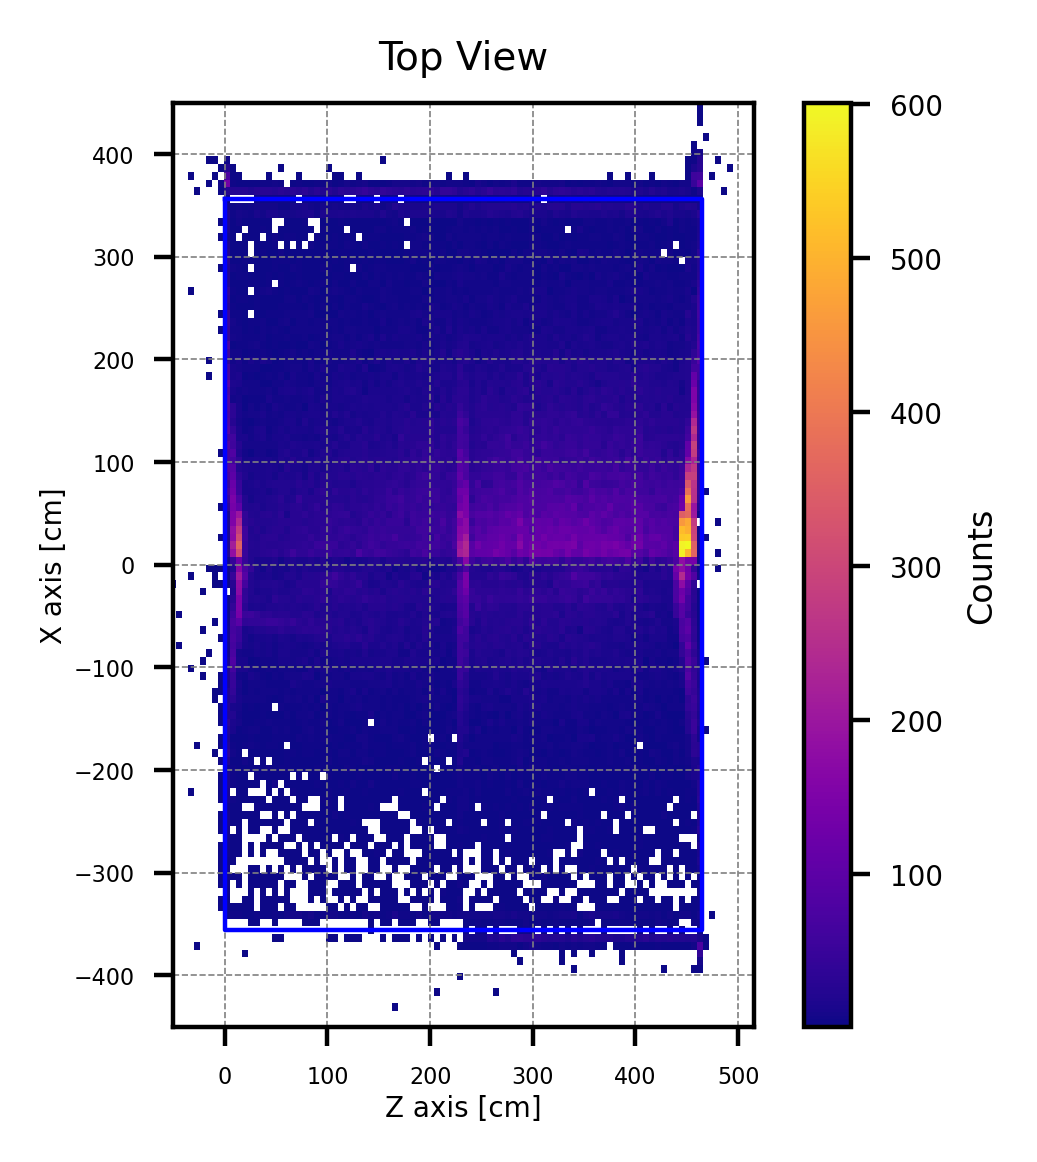

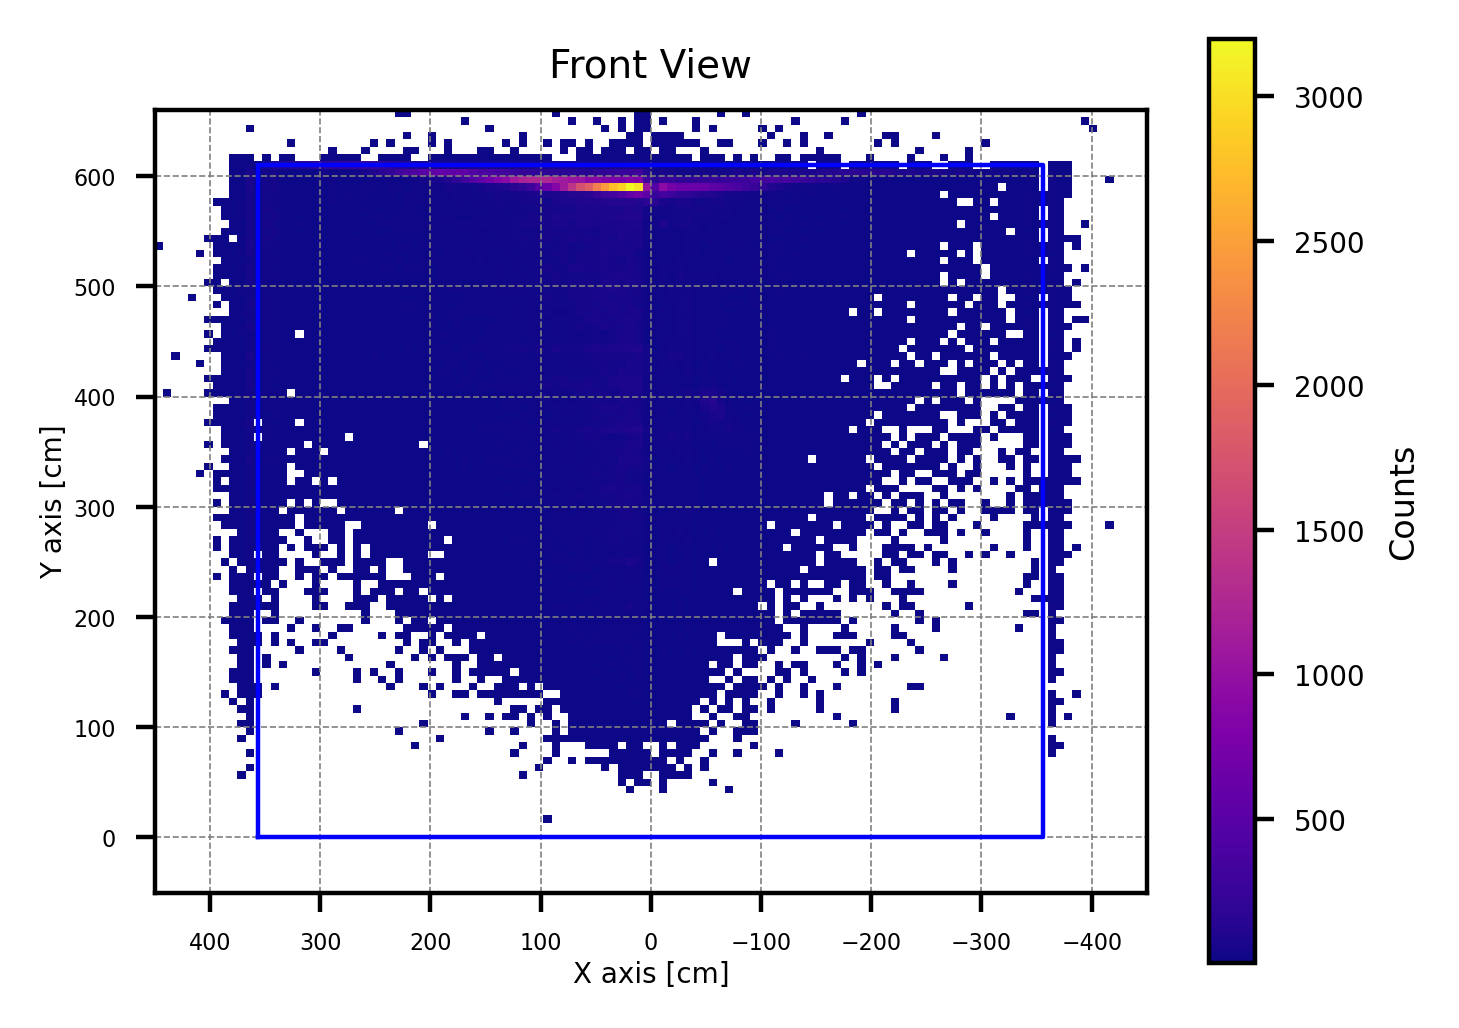

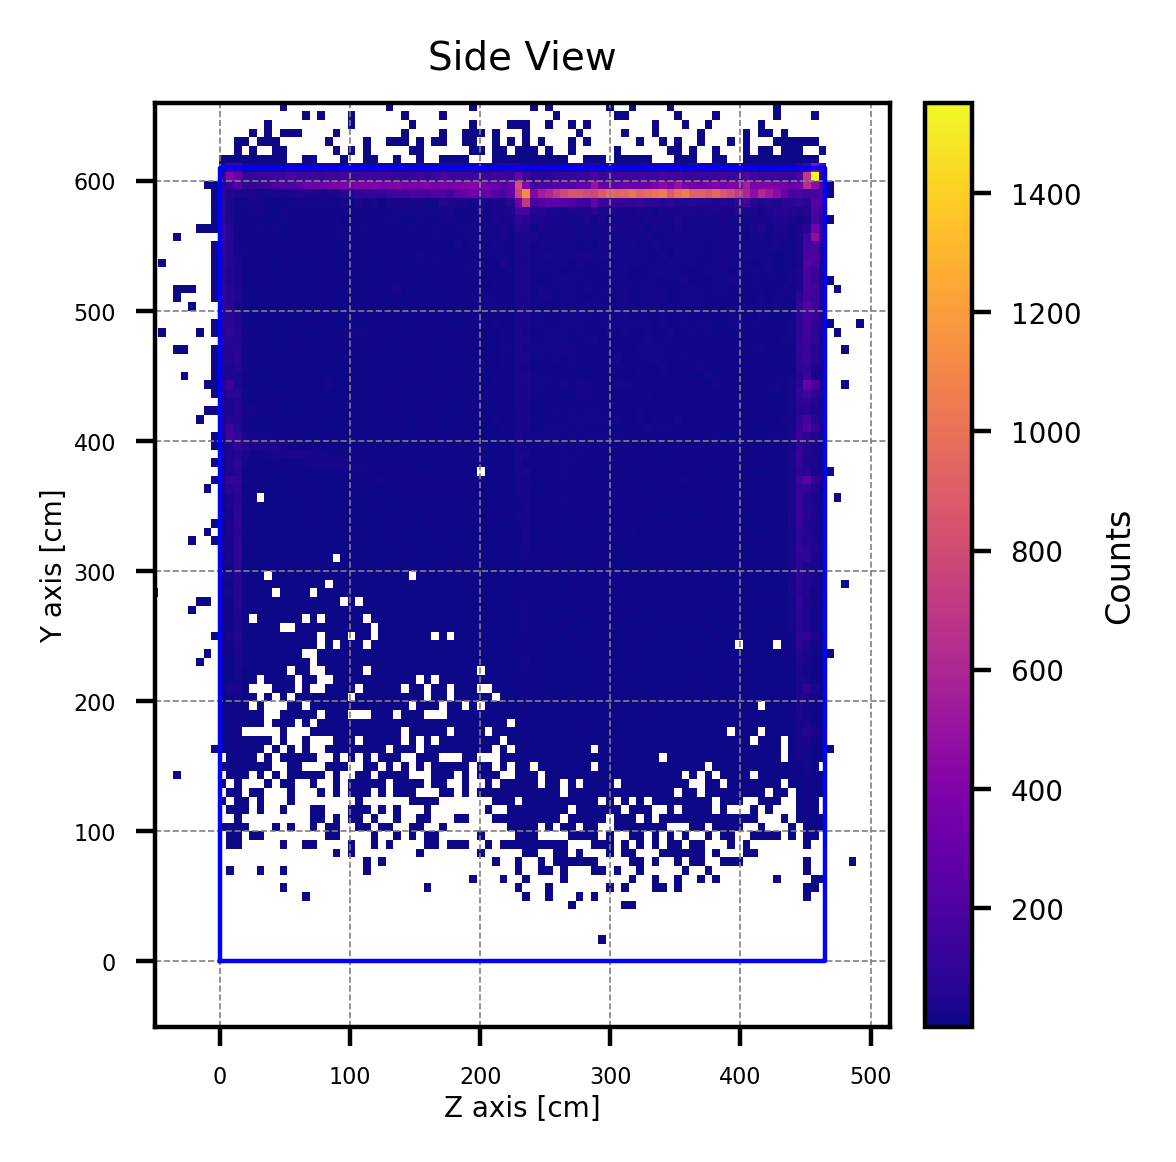

In [13]:
#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(TPC_startZ, TPC_startX, bins=(120, 120), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()





#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(TPC_startX, TPC_startY, bins=(120, 120), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 




#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(TPC_startZ, TPC_startY, bins=(120, 120), range=[[zmin, zmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.2)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
#plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Side View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 

#### Michel Score & Hits:

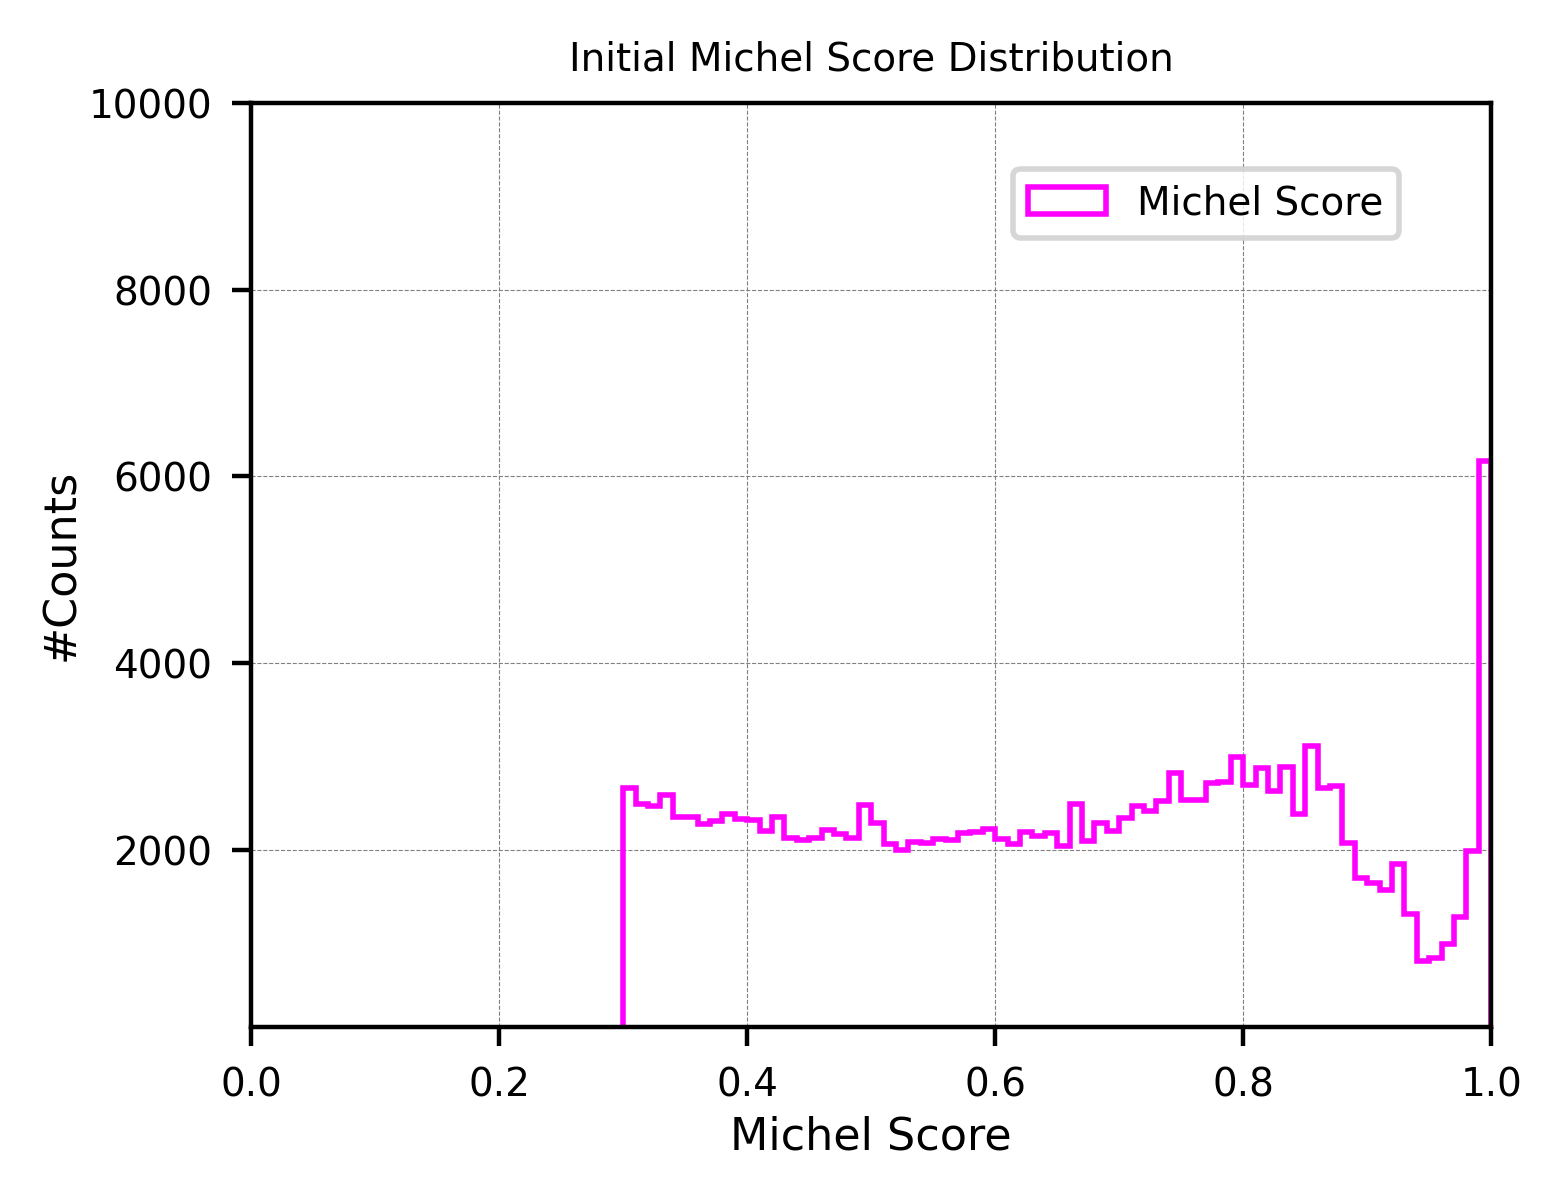

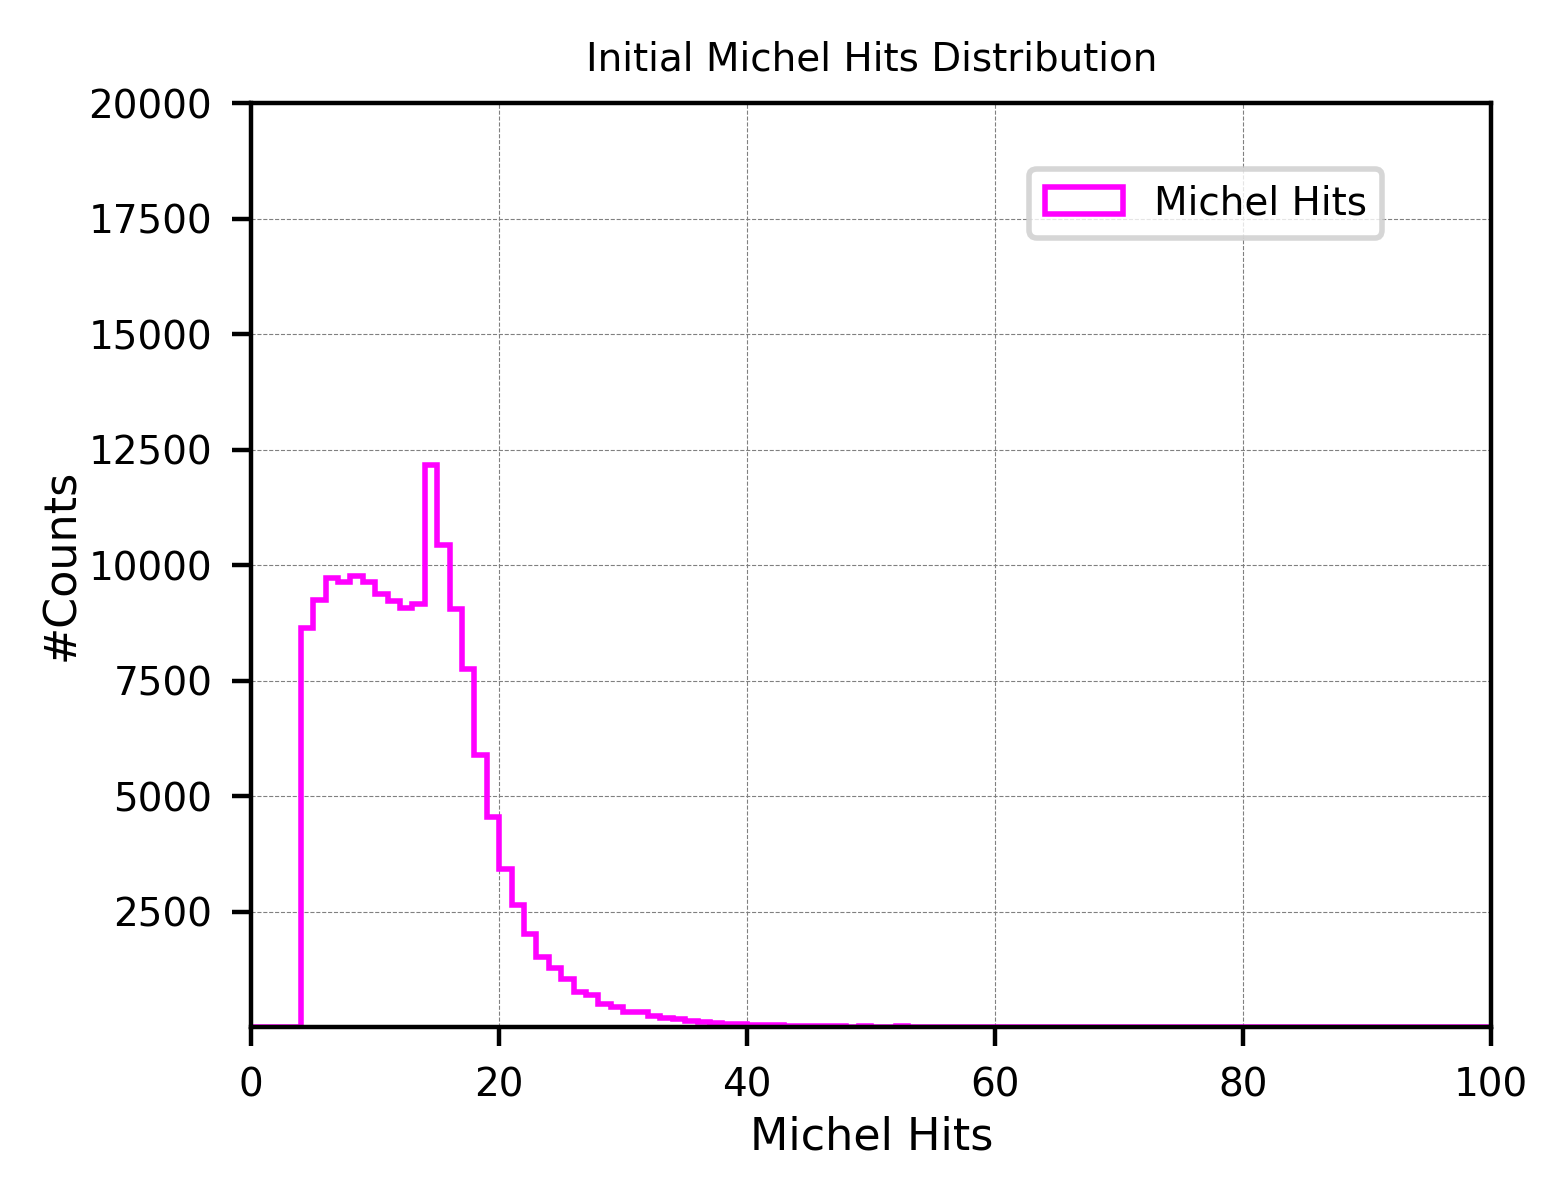

In [16]:
# Michel Score--------------------------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 0.01
range_min = 0
range_max = 1.00
bins = np.arange(range_min, range_max + bin_width, bin_width)


#plt.hist(vals_MS_initial, bins=bins, range=(range_min, range_max), edgecolor='black', 
#         histtype='step', linewidth=0.8, label="Initial")
plt.hist(TPC_MS, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=1.0, label="Michel Score")

plt.xlim(0, 1.0)
plt.xlabel('Michel Score', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(100, 10000)
#plt.yscale('log')
plt.title('Initial Michel Score Distribution', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.77, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show()  





# Michel Hits--------------------------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 1
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)


#plt.hist(vals_MH_initial, bins=bins, range=(range_min, range_max), edgecolor='black', 
#         histtype='step', linewidth=0.8, label="Initial")
plt.hist(TPC_MH, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=1.0, label="Michel Hits")


plt.xlim(0, 100)
plt.xlabel('Michel Hits', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(1, 20000)
#plt.yscale('log')
plt.title('Initial Michel Hits Distribution', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.77, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show()  

<br />
<br />
<br />
<br />

### Explore x-axis distribution asymmetry (20260614):

In [47]:
#X-Z track drawing function==============================

def draw_tracks_xz(
    event_list,
    n_tracks=1000,
    figsize=(4, 3),
    dpi=400,
    track_lw=0.4,
    track_alpha=0.5
):
    """
    Draw reconstructed tracks in the X-Z plane.

    Parameters
    ----------
    event_list : list
        List of ParticleEvent objects.
    n_tracks : int
        Number of tracks to draw.
    figsize : tuple
        Figure size.
    dpi : int
        Figure DPI.
    track_lw : float
        Track line width.
    track_alpha : float
        Track transparency.
    """

    plt.figure(figsize=figsize, dpi=dpi)

    # TPC boundary
    aux1 = [0, 465, 465, 0, 0]      # Z coordinates
    aux2 = [356, 356, -356, -356, 356]  # X coordinates

    plt.plot(
        aux1,
        aux2,
        color="orange",
        linewidth=0.8,
        linestyle="-",
        label="TPC boundary"
    )

    for event in event_list[:n_tracks]:

        # Skip incomplete events
        if (
            event.startX_initial is None
            or event.startZ_initial is None
            or event.decayX_initial is None
            or event.decayZ_initial is None
        ):
            continue

        x_values = [event.startX_initial, event.decayX_initial]
        z_values = [event.startZ_initial, event.decayZ_initial]

        plt.plot(
            z_values,
            x_values,
            linewidth=track_lw,
            alpha=track_alpha
        )

    plt.axis("scaled")
    plt.ylim(-450, 450)
    plt.xlim(-50, 515)

    plt.ylabel("X axis [cm]", labelpad=1, fontsize=5)
    plt.xlabel("Z axis [cm]", labelpad=1, fontsize=5)

    plt.tick_params(labelsize=4)
    plt.grid(color="gray",
        linestyle="--",
        linewidth=0.3,
        zorder=0
    )

    plt.tight_layout()
    plt.show()

In [48]:
#Check if a track crosses line [x1, z1) = (0, 0) and (x2, z2)= (0, 231.3)]

def segments_intersect(p1, p2, q1, q2, eps=1e-9):
    """
    Check whether two 2D line segments p1-p2 and q1-q2 intersect.

    Points are given as (x, z).
    """

    def orientation(a, b, c):
        return (
            (b[1] - a[1]) * (c[0] - b[0])
            - (b[0] - a[0]) * (c[1] - b[1])
        )

    def on_segment(a, b, c):
        return (
            min(a[0], c[0]) - eps <= b[0] <= max(a[0], c[0]) + eps
            and
            min(a[1], c[1]) - eps <= b[1] <= max(a[1], c[1]) + eps
        )

    o1 = orientation(p1, p2, q1)
    o2 = orientation(p1, p2, q2)
    o3 = orientation(q1, q2, p1)
    o4 = orientation(q1, q2, p2)

    # General intersection
    if o1 * o2 < 0 and o3 * o4 < 0:
        return True

    # Collinear / endpoint-touching cases
    if abs(o1) < eps and on_segment(p1, q1, p2):
        return True
    if abs(o2) < eps and on_segment(p1, q2, p2):
        return True
    if abs(o3) < eps and on_segment(q1, p1, q2):
        return True
    if abs(o4) < eps and on_segment(q1, p2, q2):
        return True

    return False




def split_tracks_by_APA1_boundaries(
    event_list,
    x1=0.0,
    z1=0.0,
    x2=0.0,
    z2=231.3,
    x3=-356.0,
    z3=0.0,
    x4=-356.0,
    z4=231.3
):
    """
    Split tracks according to whether they cross either APA1 boundary segment.

    Segment 1:
        (x1, z1) -> (x2, z2)

    Segment 2:
        (x3, z3) -> (x4, z4)

    If a track crosses either segment, it is saved to TPC_events_reco_APA1.
    Otherwise, it is saved to TPC_events_reco_NoAPA1.
    """

    TPC_events_reco_APA1 = []
    TPC_events_reco_NoAPA1 = []

    boundary_1_p1 = (x1, z1)
    boundary_1_p2 = (x2, z2)

    boundary_2_p1 = (x3, z3)
    boundary_2_p2 = (x4, z4)

    for event in event_list:

        if (
            event.startX_initial is None or
            event.startZ_initial is None or
            event.decayX_initial is None or
            event.decayZ_initial is None
        ):
            continue

        track_p1 = (event.startX_initial, event.startZ_initial)
        track_p2 = (event.decayX_initial, event.decayZ_initial)

        crosses_boundary_1 = segments_intersect(
            track_p1,
            track_p2,
            boundary_1_p1,
            boundary_1_p2
        )

        crosses_boundary_2 = segments_intersect(
            track_p1,
            track_p2,
            boundary_2_p1,
            boundary_2_p2
        )

        if crosses_boundary_1 or crosses_boundary_2:
            TPC_events_reco_APA1.append(event)
        else:
            TPC_events_reco_NoAPA1.append(event)

    return TPC_events_reco_NoAPA1, TPC_events_reco_APA1




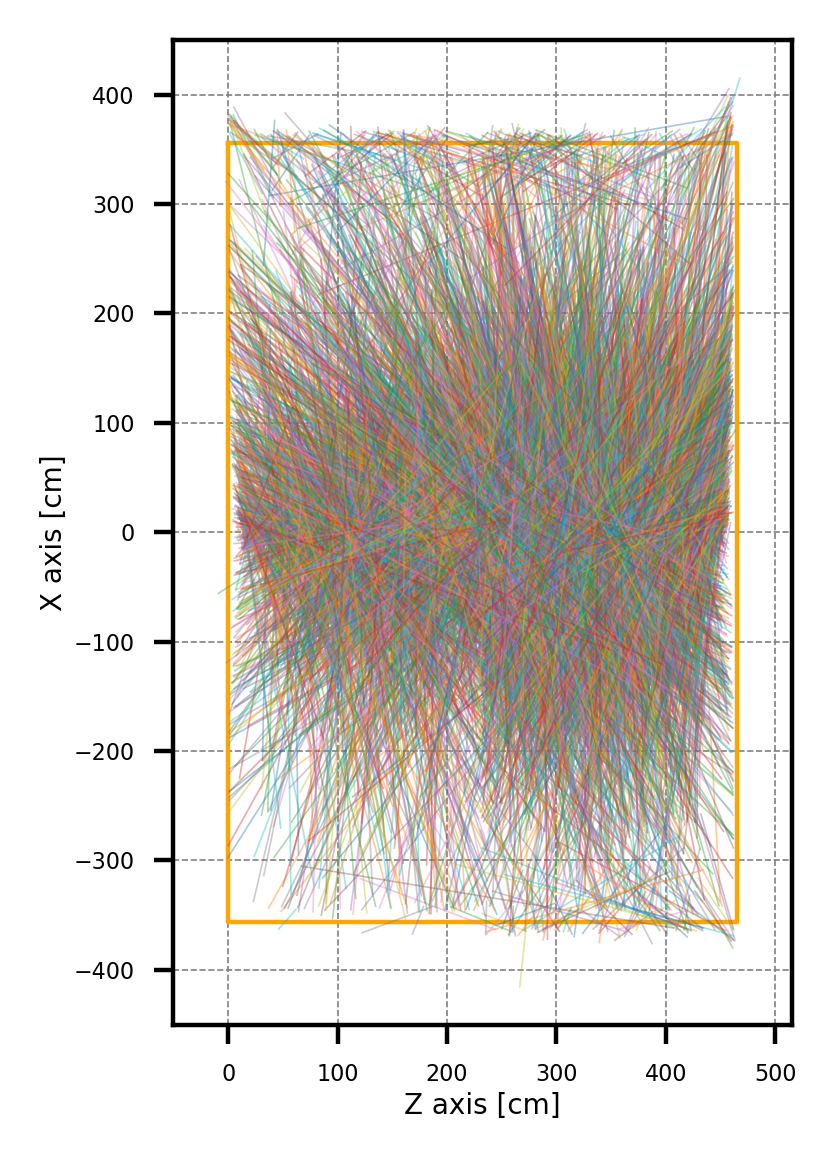

TPC_events_reco :  159651
No APA1 crossing:  120006 (75.17%)
APA1 crossing   :  39645 (24.83%)


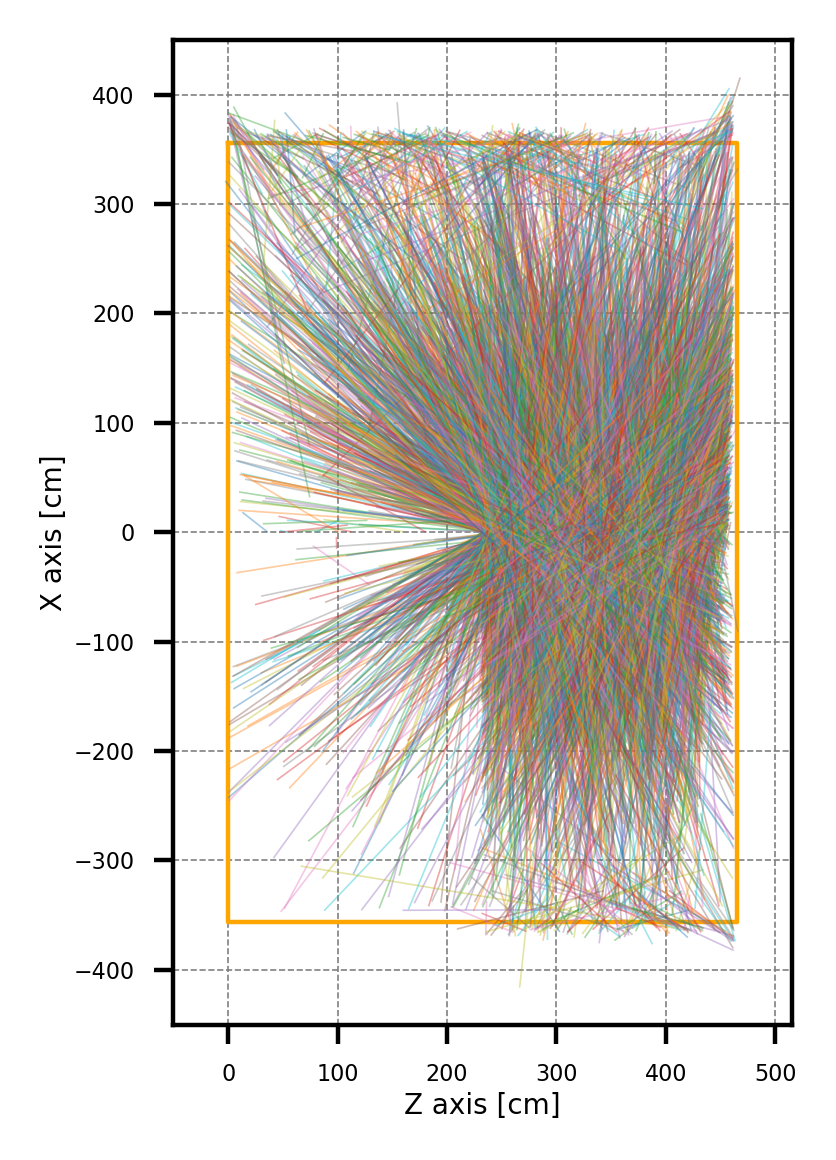

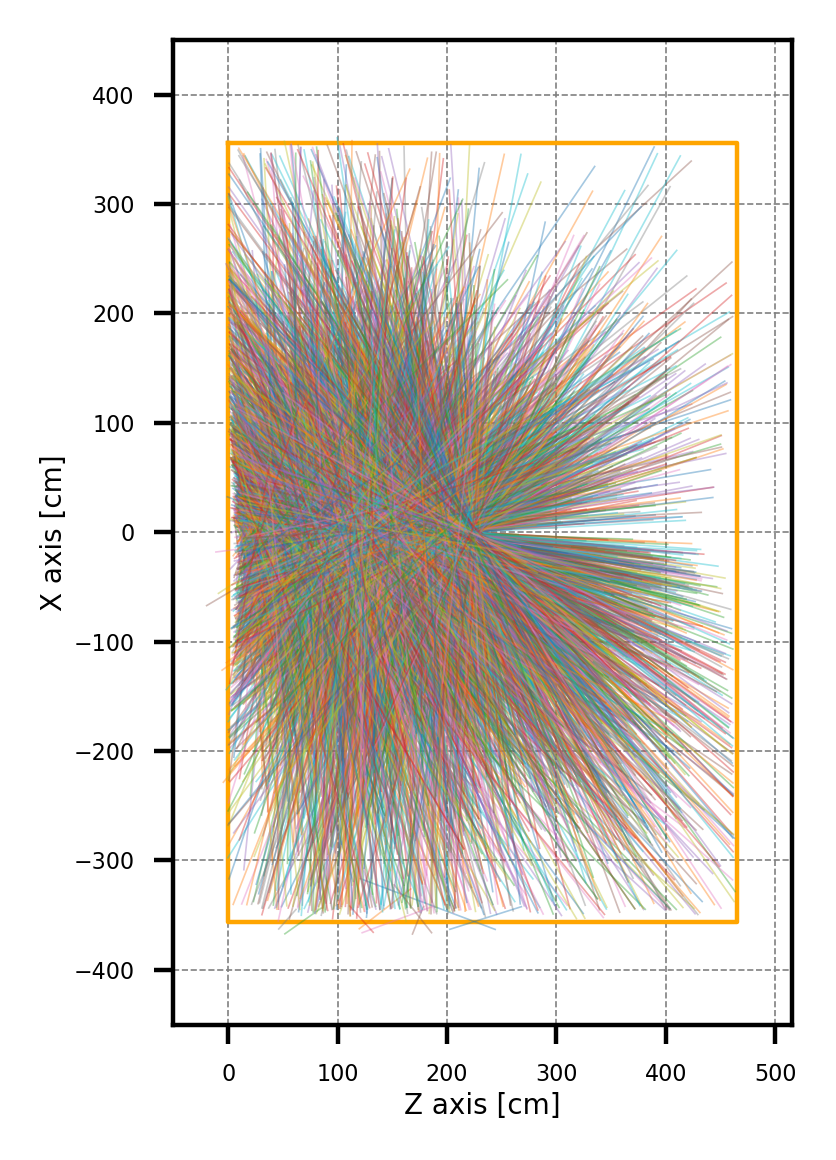

In [52]:
# Tracks after TPC cuts------
draw_tracks_xz(TPC_events_reco, n_tracks=10000, track_lw=0.3, track_alpha=0.4)


# Check APA1 crossing------
TPC_events_reco_NoAPA1, TPC_events_reco_APA1 = split_tracks_by_APA1_boundaries(
    TPC_events_reco
)

print("TPC_events_reco : ", len(TPC_events_reco))
print("No APA1 crossing: ", len(TPC_events_reco_NoAPA1),
      "({:.2f}%)".format(len(TPC_events_reco_NoAPA1)/len(TPC_events_reco)*100))
print("APA1 crossing   : ", len(TPC_events_reco_APA1),
      "({:.2f}%)".format(len(TPC_events_reco_APA1)/len(TPC_events_reco)*100))

draw_tracks_xz(TPC_events_reco_NoAPA1, n_tracks=10000, track_lw=0.3, track_alpha=0.4)
draw_tracks_xz(TPC_events_reco_APA1, n_tracks=10000, track_lw=0.3, track_alpha=0.4)


<br />
<br />


### Stopping points distributions: X projection and Top View

Decay points distribution (After TPC cut): 
# of X < 0 :  93134 (77.608%)
# of X >= 0:  26872 (22.392%)

Decay points in 4 APA regions:
# APA1:  2455 (2.05%)
# APA2:  90679 (75.56%)
# APA3:  5739 (4.78%)
# APA4:  21133 (17.61%)


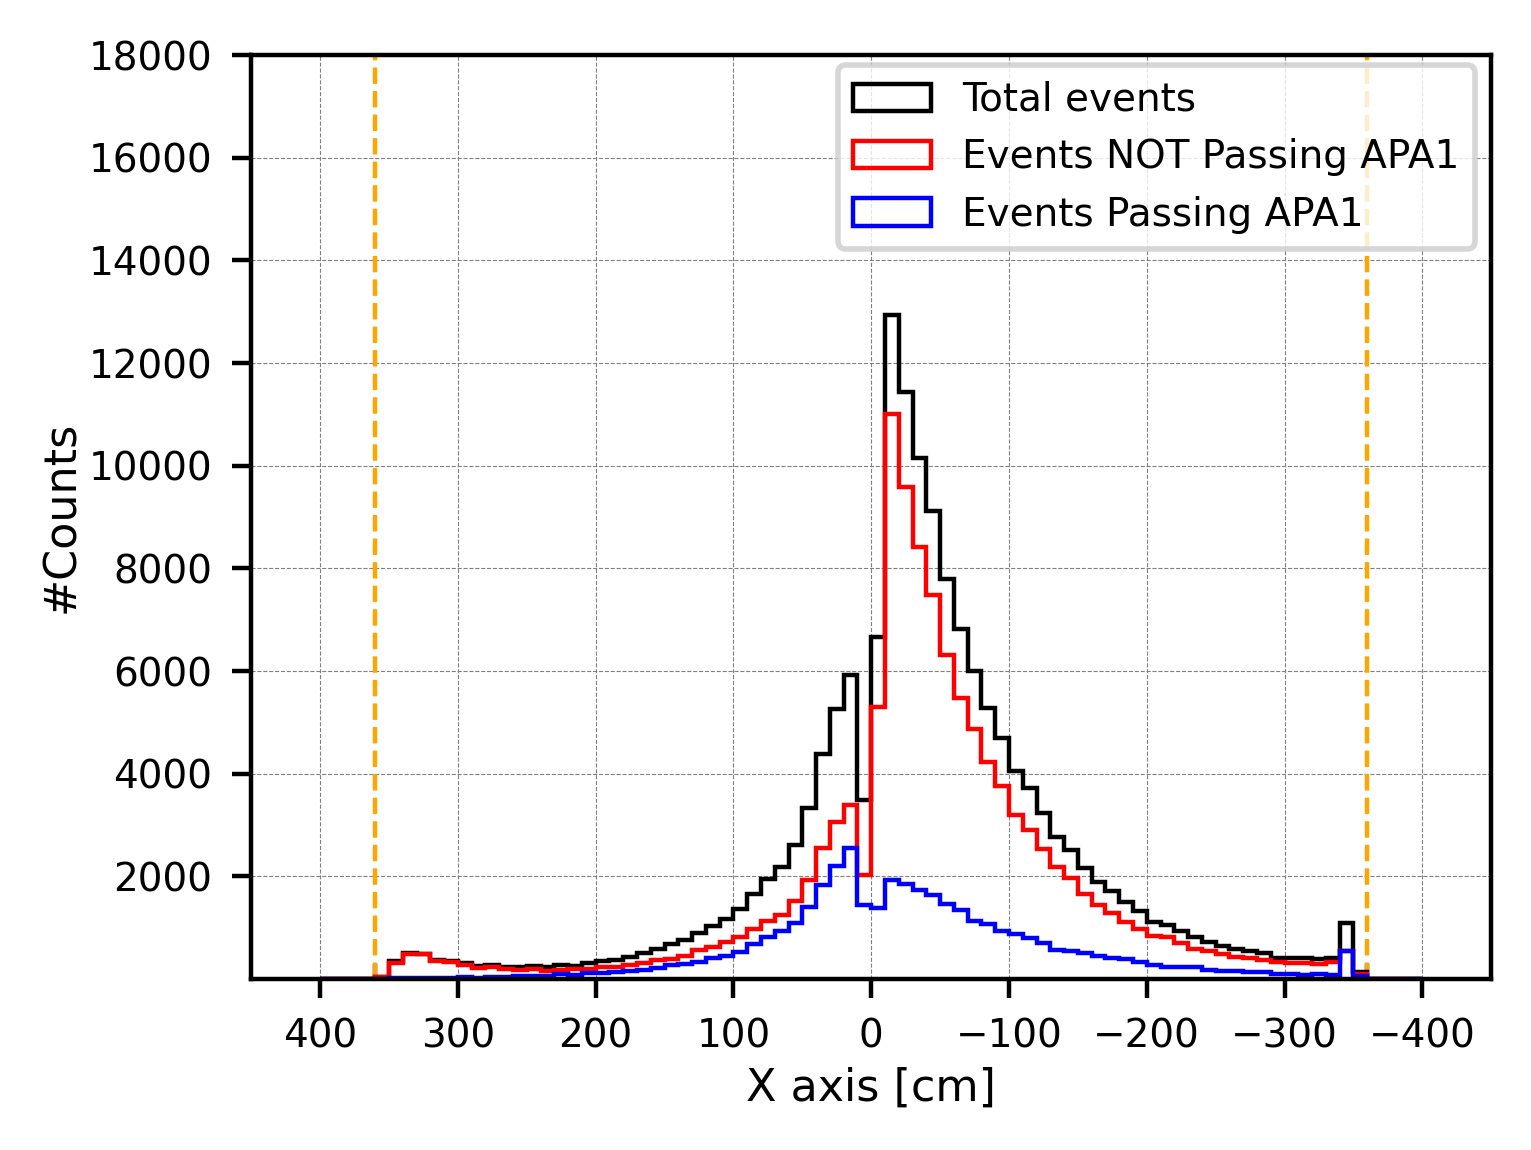

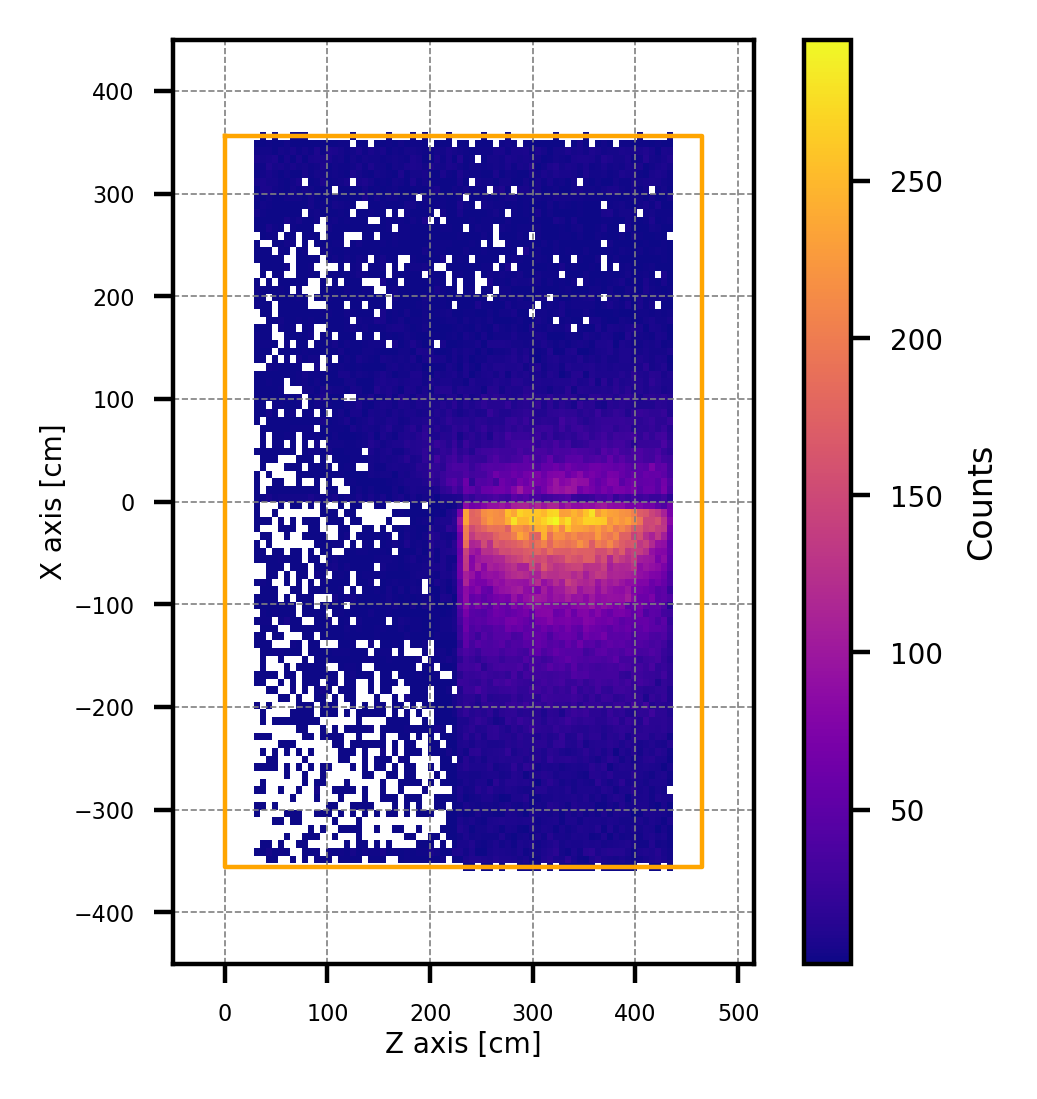

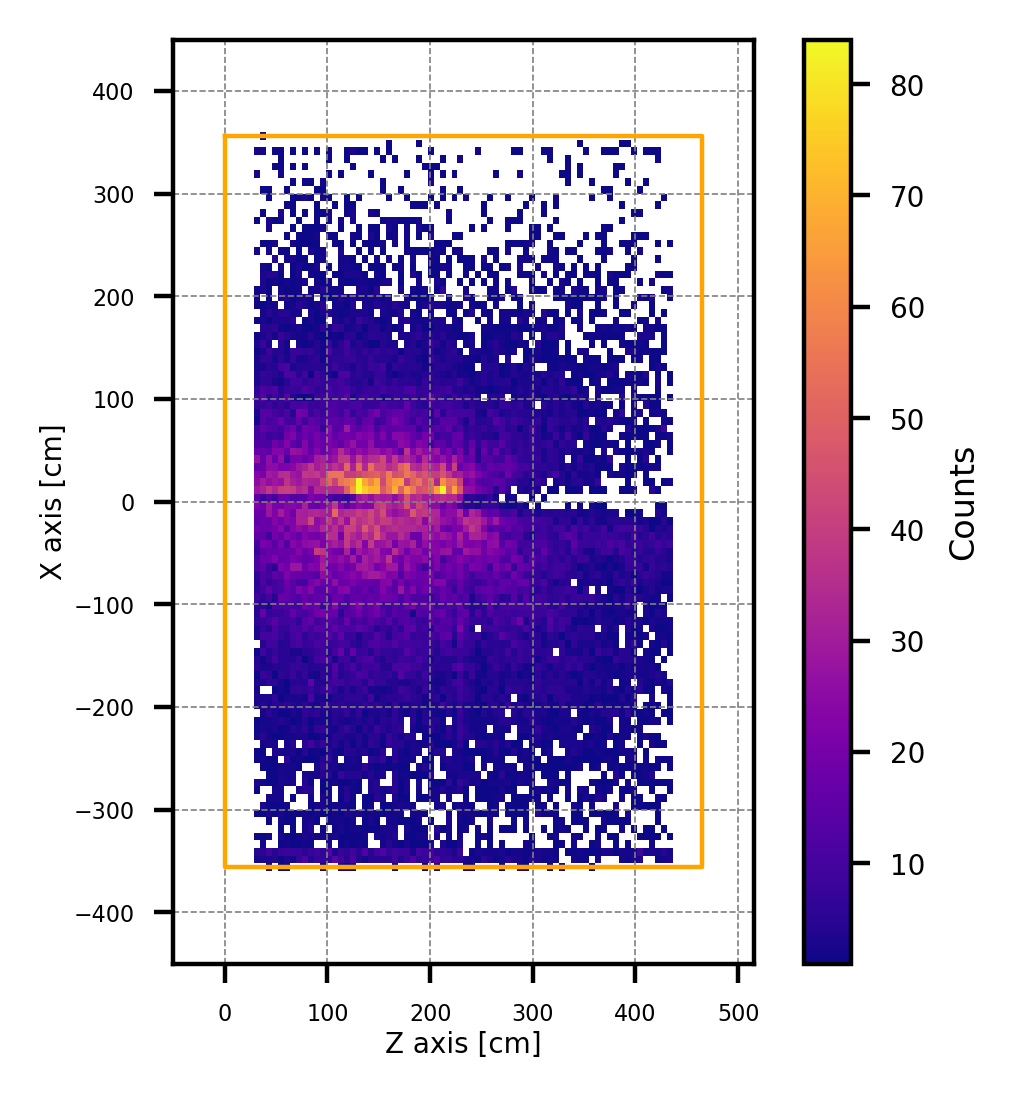

In [55]:


vals_decayX_NoAPA1 = [ev.decayX_initial for ev in TPC_events_reco_NoAPA1]
vals_decayX_APA1 = [ev.decayX_initial for ev in TPC_events_reco_APA1]
vals_decayZ_NoAPA1 = [ev.decayZ_initial for ev in TPC_events_reco_NoAPA1]
vals_decayZ_APA1 = [ev.decayZ_initial for ev in TPC_events_reco_APA1]





#Calculate the percentage--------------------
#Decay points distribution:==========================================
print("Decay points distribution (After TPC cut): ")

vals_decayX_NoAPA1 = np.array(vals_decayX_NoAPA1)
neg_X_noAPA1 = np.sum(vals_decayX_NoAPA1 < 0)
pos_X_noAPA1 = np.sum(vals_decayX_NoAPA1 >= 0)
print("# of X < 0 : ", neg_X_noAPA1, 
      "({:.3f}%)".format(neg_X_noAPA1/len(vals_decayX_NoAPA1)*100))
print("# of X >= 0: ", pos_X_noAPA1, 
      "({:.3f}%)".format(pos_X_noAPA1/len(vals_decayX_NoAPA1)*100))




# Decay points in 4 APA regions
# APA1: X <= 0, Z <= 231.266
# APA2: X <= 0, Z >  231.266
# APA3: X >  0, Z <= 231.266
# APA4: X >  0, Z >  231.266

vals_decayZ_NoAPA1 = np.array(vals_decayZ_NoAPA1)

z_split = 231.266
n_total = len(vals_decayX_NoAPA1)

n_apa1 = np.sum((vals_decayX_NoAPA1 <= 0) & (vals_decayZ_NoAPA1 <= z_split))
n_apa2 = np.sum((vals_decayX_NoAPA1 <= 0) & (vals_decayZ_NoAPA1 >  z_split))
n_apa3 = np.sum((vals_decayX_NoAPA1 >  0) & (vals_decayZ_NoAPA1 <= z_split))
n_apa4 = np.sum((vals_decayX_NoAPA1 >  0) & (vals_decayZ_NoAPA1 >  z_split))

print("\nDecay points in 4 APA regions:")
print("# APA1: ", n_apa1, "({:.2f}%)".format(n_apa1 / n_total * 100))
print("# APA2: ", n_apa2, "({:.2f}%)".format(n_apa2 / n_total * 100))
print("# APA3: ", n_apa3, "({:.2f}%)".format(n_apa3 / n_total * 100))
print("# APA4: ", n_apa4, "({:.2f}%)".format(n_apa4 / n_total * 100))





#Decay points distribution:==========================================
# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-360, -360], [0, 300], color="blue", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 300], color="blue", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

#APA planes---
plt.plot([-360, -360], [0, 30000], color="orange", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 30000], color="orange", linewidth=0.8, linestyle='--')

plt.hist(TPC_X, bins=bins, range=(range_min, range_max), edgecolor='black', 
         histtype='step', linewidth=0.8, label="Total events")
plt.hist(vals_decayX_NoAPA1, bins=bins, range=(range_min, range_max), edgecolor='red', 
         histtype='step', linewidth=0.8, label="Events NOT Passing APA1")
plt.hist(vals_decayX_APA1, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=0.8, label="Events Passing APA1")


plt.xlim(-450, 450)
plt.xlabel('X axis [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0.9, 18000)
#plt.yscale('log')
#plt.title('Distribution Along Drift Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.73, 1.01), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.savefig('ch8_decayX_tpcCut_MC.png', dpi=600, bbox_inches='tight')

plt.show() 





#Z-X plane ploting (Top View) (No passing)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="orange", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayZ_NoAPA1, vals_decayX_NoAPA1, 
    bins=(120, 120), range=[[zmin, zmax], [xmin, xmax]],
    cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
#plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

plt.show()






#Z-X plane ploting (Top View) (passing)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="orange", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayZ_APA1, vals_decayX_APA1, 
    bins=(120, 120), range=[[zmin, zmax], [xmin, xmax]],
    cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
#plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

plt.show()






### New Data MC Comparison

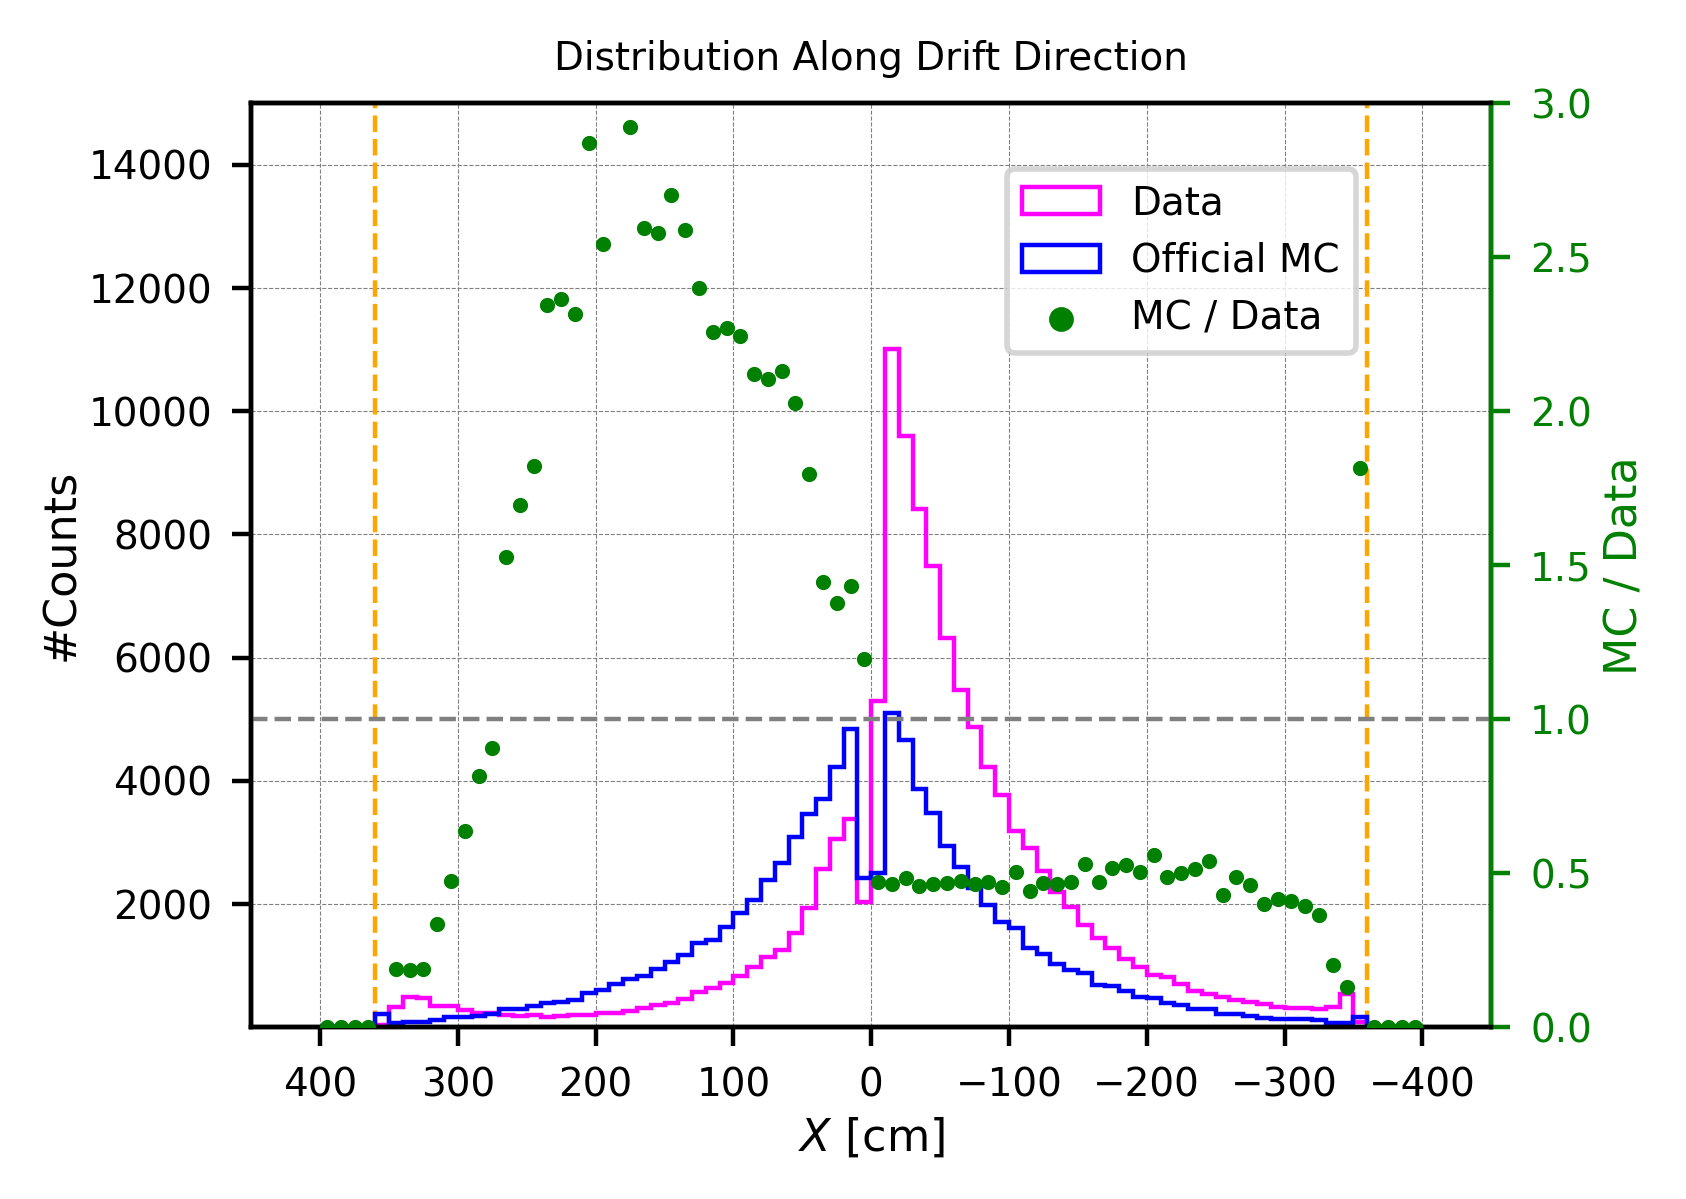

In [57]:
import numpy as np
import matplotlib.pyplot as plt

decayX_noAPA1Cross_MC = np.load("../MC_official2025/decayX_noAPA1Cross_MC.npy")

# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4, 3), dpi=400)

# Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histograms for ratio calculation
data_counts, _ = np.histogram(vals_decayX_NoAPA1, bins=bins, range=(range_min, range_max))
mc_counts, _   = np.histogram(decayX_noAPA1Cross_MC, bins=bins, range=(range_min, range_max))

# Bin centers
bin_centers = (bins[:-1] + bins[1:]) / 2

# Ratio = MC / Data
ratio = np.divide(
    mc_counts,
    data_counts,
    out=np.zeros_like(mc_counts, dtype=float),
    where=data_counts != 0
)

# Main axis
ax1 = plt.gca()

# APA planes
ax1.plot([-360, -360], [0, 15000], color="orange", linewidth=0.8, linestyle='--')
ax1.plot([360, 360], [0, 15000], color="orange", linewidth=0.8, linestyle='--')

# Histograms
ax1.hist(
    vals_decayX_NoAPA1,
    bins=bins,
    range=(range_min, range_max),
    edgecolor='magenta',
    histtype='step',
    linewidth=0.8,
    label="Data"
)

ax1.hist(
    decayX_noAPA1Cross_MC,
    bins=bins,
    range=(range_min, range_max),
    edgecolor='blue',
    histtype='step',
    linewidth=0.8,
    label="Official MC"
)

# Main axis formatting
ax1.set_xlim(-450, 450)
ax1.set_xlabel(r'$X$ [cm]', labelpad=2, fontsize=8)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=8)
ax1.invert_xaxis()
ax1.set_ylim(0.1, 15000)
# ax1.set_yscale('log')
ax1.set_title('Distribution Along Drift Direction', fontsize=7)
ax1.tick_params(labelsize=7)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

# Right y-axis for ratio
ax2 = ax1.twinx()

ax2.scatter(
    bin_centers,
    ratio,
    color='green',
    s=3,
    label='MC / Data',
    zorder=5
)

ax2.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
ax2.set_ylabel('MC / Data', labelpad=2, fontsize=8, color="green")
ax2.set_ylim(0, 3)
ax2.tick_params(axis='y', labelsize=7, colors="green")
ax2.spines['right'].set_color("green")

# Combined legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc='upper center',
    bbox_to_anchor=(0.75, 0.95),
    fontsize=7,
    markerscale=2,
    ncol=1,
    prop={'size': 7}
)

plt.show()